In [ ]:
import subprocess, sys

# Nettoyer
subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", 
                       "facenet-pytorch"])

# Installer juste les dépendances de base
subprocess.check_call([sys.executable, "-m", "pip", "install", 
                       "pillow==11.0.0",
                       "torchvision==0.17.2",
                       "scikit-learn",
                       "matplotlib"])

print("\n" + "="*70)
print("VÉRIFICATION FINALE")
print("="*70)

import torch
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")

import numpy as np
print(f"✅ NumPy: {np.__version__}")

import torchvision.models as models
print("✅ TorchVision: OK")
print("✅ MobileNetV3: Prêt à être utilisé (fallback)")

print("="*70)

In [ ]:
import subprocess, sys

# Redémarrer le kernel (nettoyer la mémoire)
subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "numpy==2.0.2"])

print("\n✅ NumPy mis à jour")
print("⚠️  REDÉMARRE LE KERNEL maintenant !")
print("Clique sur : Kernel → Restart Kernel")

Device: cuda
Train: 343 | Val: 74 | Test: 74
Personnes valides: 343/343


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Personnes valides: 74/74
⚠️  facenet-pytorch non installé — Fallback MobileNetV3
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 153MB/s]


Modèle : MobileNetV3-Large (fallback)
Paramètres entraînables : 3,091,424

DÉBUT DE L'ENTRAÎNEMENT
Epoch 01/20 | Train: 0.1367 (50.3% actifs) | Val: 0.1104 (33.5% actifs) | LR: 2.98e-04 | 158s
   💾 Sauvegardé — val=0.1104
Epoch 02/20 | Train: 0.0931 (35.4% actifs) | Val: 0.0957 (30.1% actifs) | LR: 2.93e-04 | 115s
   💾 Sauvegardé — val=0.0957
Epoch 03/20 | Train: 0.0803 (31.2% actifs) | Val: 0.0875 (27.6% actifs) | LR: 2.84e-04 | 114s
   💾 Sauvegardé — val=0.0875
Epoch 04/20 | Train: 0.0691 (28.0% actifs) | Val: 0.0871 (27.7% actifs) | LR: 2.71e-04 | 115s
   💾 Sauvegardé — val=0.0871
Epoch 05/20 | Train: 0.0636 (25.9% actifs) | Val: 0.0832 (26.6% actifs) | LR: 2.56e-04 | 117s
   💾 Sauvegardé — val=0.0832
Epoch 06/20 | Train: 0.0589 (24.4% actifs) | Val: 0.0796 (26.3% actifs) | LR: 2.38e-04 | 119s
   💾 Sauvegardé — val=0.0796
Epoch 07/20 | Train: 0.0571 (23.9% actifs) | Val: 0.0799 (27.2% actifs) | LR: 2.18e-04 | 118s
   ⏳ Pas d'amélioration (1/8)
Epoch 08/20 | Train: 0.0518 (22.8% acti

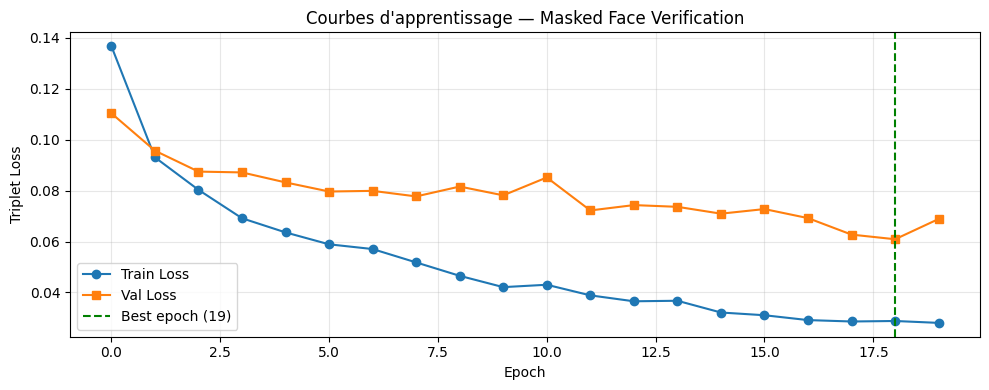


Évaluation sur le jeu de test...
ROC AUC : 0.9117


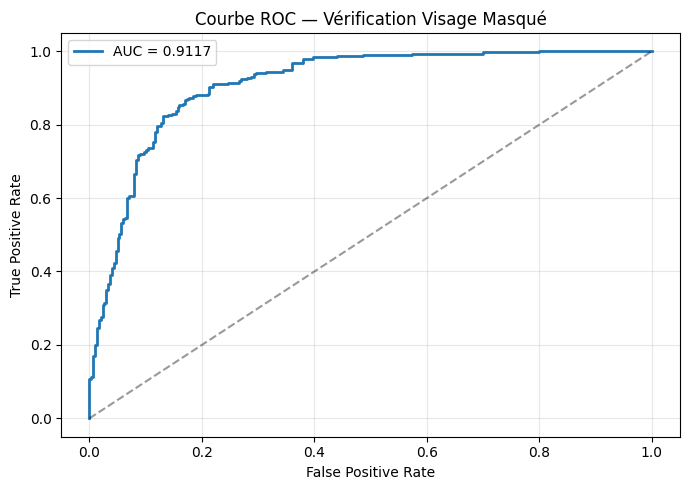

Seuil optimal : 0.4503
TPR           : 0.8667
FPR           : 0.1700


/tmp/ipykernel_105/272095611.py:484: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_105/272095611.py:485: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/kaggle/working/predictions.png", dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


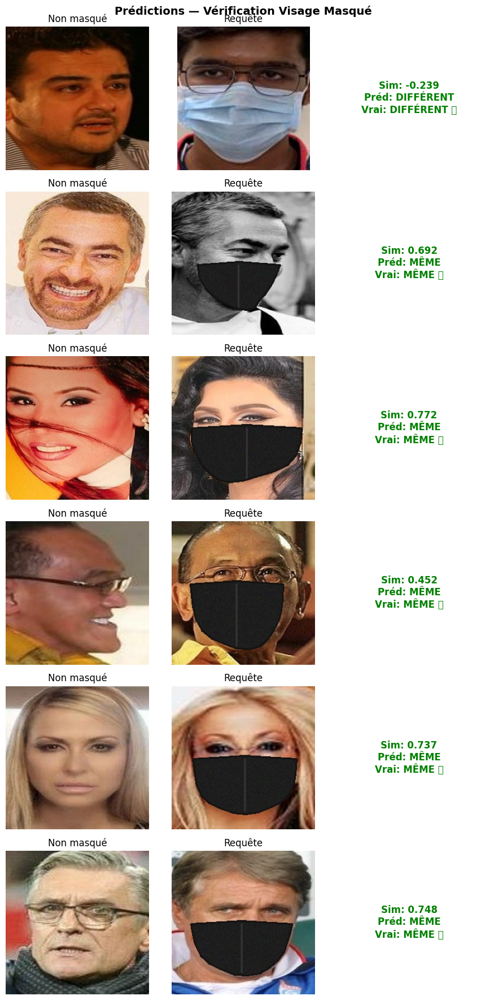


✅ Modèle sauvegardé : /kaggle/working/face_verification_model.pt
   AUC       : 0.9117
   Seuil opt : 0.4503
📥 Clique sur chaque lien pour télécharger sur ton PC :

   ✅ best_model.pt — 13.2 MB


/kaggle/working/best_model.pt

   ✅ face_verification_model.pt — 13.2 MB


/kaggle/working/face_verification_model.pt

   ✅ learning_curves.png — 0.1 MB


/kaggle/working/learning_curves.png

   ✅ roc_curve.png — 0.1 MB


/kaggle/working/roc_curve.png

   ✅ predictions.png — 2.3 MB


/kaggle/working/predictions.png

In [1]:
# ============================================================
# MASKED FACE VERIFICATION — FaceNet + Triplet Loss
# Version corrigée complète
# ============================================================

# ====================
# 1. IMPORTS
# ====================
import os, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


# ====================
# 2. CHEMIN + SPLIT DATASET
# ====================
root = "/kaggle/input/datasets/hibaelhamdani/data-dl/Unified_Dataset"

persons = [p for p in os.listdir(root) if os.path.isdir(os.path.join(root, p))]
random.shuffle(persons)

train_split = int(0.70 * len(persons))
val_split   = int(0.85 * len(persons))

train_persons = persons[:train_split]
val_persons   = persons[train_split:val_split]
test_persons  = persons[val_split:]

print(f"Train: {len(train_persons)} | Val: {len(val_persons)} | Test: {len(test_persons)}")


# ====================
# 3. TRANSFORMS
# ====================
IMG_SIZE = 160  # FaceNet standard

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.4, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


# ====================
# 4. TRIPLET DATASET
# ====================
class TripletDataset(Dataset):
    def __init__(self, root, persons, transform=None, length=10000):
        self.root      = root
        self.transform = transform
        self.length    = length

        # Pré-indexer les chemins
        self.index = {}
        for p in persons:
            self.index[p] = {}
            for t in ["masked", "non_masked"]:
                path = os.path.join(root, p, t)
                if os.path.exists(path):
                    files = [f for f in os.listdir(path)
                             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
                    self.index[p][t] = files
                else:
                    self.index[p][t] = []

        # Garder uniquement les personnes avec les deux types
        self.valid_persons = [
            p for p in persons
            if len(self.index[p].get("masked", [])) > 0
            and len(self.index[p].get("non_masked", [])) > 0
        ]
        print(f"Personnes valides: {len(self.valid_persons)}/{len(persons)}")

    def _load(self, person, img_type):
        fname = random.choice(self.index[person][img_type])
        path  = os.path.join(self.root, person, img_type, fname)
        return Image.open(path).convert("RGB")

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Stratégie équilibrée
        r = random.random()
        if r < 0.50:
            anchor_type, positive_type = "non_masked", "masked"
        elif r < 0.75:
            anchor_type, positive_type = "masked", "masked"
        else:
            anchor_type, positive_type = "non_masked", "non_masked"

        person = random.choice(self.valid_persons)
        A = self._load(person, anchor_type)
        P = self._load(person, positive_type)

        neg_person = random.choice([p for p in self.valid_persons if p != person])
        neg_type   = random.choice(["masked", "non_masked"])
        N = self._load(neg_person, neg_type)

        if self.transform:
            A = self.transform(A)
            P = self.transform(P)
            N = self.transform(N)

        return A, P, N


# ====================
# 5. DATALOADER
# ====================
BATCH_SIZE = 32

train_dataset = TripletDataset(root, train_persons, train_transform, length=10000)
val_dataset   = TripletDataset(root, val_persons,   val_transform,   length=3000)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)


# ====================
# 6. MODÈLE — FaceNet
# ====================
try:
    from facenet_pytorch import InceptionResnetV1

    class FaceNetModel(nn.Module):
        def __init__(self, embedding_dim=128, dropout=0.4):
            super().__init__()
            self.backbone = InceptionResnetV1(pretrained='vggface2')

            # Geler les premières couches
            for name, param in self.backbone.named_parameters():
                if not any(k in name for k in ['block8', 'avgpool', 'last_linear', 'last_bn']):
                    param.requires_grad = False

            self.projector = nn.Sequential(
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(256, embedding_dim),
            )

        def forward(self, x):
            feat = self.backbone(x)
            return self.projector(feat)

    MODEL_NAME = "FaceNet (InceptionResnetV1)"
    model = FaceNetModel(embedding_dim=128, dropout=0.4).to(DEVICE)
    print("✅ FaceNet chargé!")

except ImportError:
    print("⚠️  facenet-pytorch non installé — Fallback MobileNetV3")

    class FaceNetModel(nn.Module):
        def __init__(self, embedding_dim=128, dropout=0.4):
            super().__init__()
            base = models.mobilenet_v3_large(pretrained=True)

            children = list(base.features.children())
            for block in children[:10]:
                for p in block.parameters():
                    p.requires_grad = False

            self.features = base.features
            self.pool = nn.AdaptiveAvgPool2d(1)
            self.head = nn.Sequential(
                nn.Flatten(),
                nn.Linear(960, 256),
                nn.BatchNorm1d(256),
                nn.Hardswish(),
                nn.Dropout(dropout),
                nn.Linear(256, embedding_dim),
            )

        def forward(self, x):
            x = self.features(x)
            x = self.pool(x)
            return self.head(x)

    MODEL_NAME = "MobileNetV3-Large (fallback)"
    model = FaceNetModel(embedding_dim=128, dropout=0.4).to(DEVICE)

print(f"Modèle : {MODEL_NAME}")
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Paramètres entraînables : {total_params:,}")


# ====================
# 7. TRIPLET LOSS
# ====================
def triplet_loss(a, p, n, margin=0.3):
    d_ap = F.pairwise_distance(a, p, p=2)
    d_an = F.pairwise_distance(a, n, p=2)
    loss = F.relu(d_ap - d_an + margin)
    active_ratio = (loss > 0).float().mean().item()
    return loss.mean(), active_ratio


# ====================
# 8. TRAINING — TOUTES LES EPOCHS GARANTIES
# ====================
EPOCHS       = 20
LR           = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE     = 8        # Suffisamment de patience
MIN_DELTA    = 1e-4     # Amélioration minimale pour compter

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda')

train_losses, val_losses = [], []
best_val_loss    = float('inf')
patience_counter = 0

print("\n" + "="*60)
print("DÉBUT DE L'ENTRAÎNEMENT")
print("="*60)

for epoch in range(EPOCHS):
    t0 = time.time()

    # ── TRAIN ──
    model.train()
    train_loss   = 0.0
    train_active = 0.0
    n_batches    = 0

    for A, P, N in train_loader:
        A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)

        with torch.amp.autocast('cuda'):
            A_emb = F.normalize(model(A), dim=1)
            P_emb = F.normalize(model(P), dim=1)
            N_emb = F.normalize(model(N), dim=1)
            loss, active = triplet_loss(A_emb, P_emb, N_emb)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss   += loss.item()
        train_active += active
        n_batches    += 1

    scheduler.step()

    # ── VALIDATION ──
    model.eval()
    val_loss   = 0.0
    val_active = 0.0
    n_val      = 0

    with torch.no_grad():
        for A, P, N in val_loader:
            A, P, N = A.to(DEVICE), P.to(DEVICE), N.to(DEVICE)
            with torch.amp.autocast('cuda'):
                A_emb = F.normalize(model(A), dim=1)
                P_emb = F.normalize(model(P), dim=1)
                N_emb = F.normalize(model(N), dim=1)
                loss, active = triplet_loss(A_emb, P_emb, N_emb)
            val_loss   += loss.item()
            val_active += active
            n_val      += 1

    avg_train = train_loss   / n_batches
    avg_val   = val_loss     / n_val
    train_losses.append(avg_train)
    val_losses.append(avg_val)

    elapsed = time.time() - t0
    lr_now  = scheduler.get_last_lr()[0]

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train: {avg_train:.4f} ({train_active/n_batches:.1%} actifs) | "
          f"Val: {avg_val:.4f} ({val_active/n_val:.1%} actifs) | "
          f"LR: {lr_now:.2e} | {elapsed:.0f}s")

    # ── SAVE BEST + EARLY STOPPING ──
    if avg_val < best_val_loss - MIN_DELTA:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pt")
        print(f"   💾 Sauvegardé — val={avg_val:.4f}")
    else:
        patience_counter += 1
        print(f"   ⏳ Pas d'amélioration ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n⏹  Early stopping — epoch {epoch+1}")
            break

print(f"\n✅ Fin. Meilleure val loss: {best_val_loss:.4f}")


# ====================
# 9. COURBES D'APPRENTISSAGE
# ====================
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(val_losses,   label="Val Loss",   marker='s')
plt.axvline(x=np.argmin(val_losses), color='green', linestyle='--',
            label=f"Best epoch ({np.argmin(val_losses)+1})")
plt.xlabel("Epoch")
plt.ylabel("Triplet Loss")
plt.title("Courbes d'apprentissage — Masked Face Verification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/learning_curves.png", dpi=150)
plt.show()


# ====================
# 10. ÉVALUATION — ROC AUC
# ====================
model.load_state_dict(torch.load("/kaggle/working/best_model.pt"))
model.eval()

def build_embeddings(persons_list, transform, n_samples=300):
    pairs_emb, pairs_label = [], []

    # Pré-filtrer les personnes valides
    valid = [
        p for p in persons_list
        if os.path.exists(os.path.join(root, p, "masked"))
        and os.path.exists(os.path.join(root, p, "non_masked"))
        and len(os.listdir(os.path.join(root, p, "masked"))) > 0
        and len(os.listdir(os.path.join(root, p, "non_masked"))) > 0
    ]

    with torch.no_grad():
        for _ in range(n_samples):
            person = random.choice(valid)

            img1 = Image.open(os.path.join(
                root, person, "non_masked",
                random.choice(os.listdir(os.path.join(root, person, "non_masked")))
            )).convert("RGB")
            img2 = Image.open(os.path.join(
                root, person, "masked",
                random.choice(os.listdir(os.path.join(root, person, "masked")))
            )).convert("RGB")

            e1 = F.normalize(model(transform(img1).unsqueeze(0).to(DEVICE)), dim=1)
            e2 = F.normalize(model(transform(img2).unsqueeze(0).to(DEVICE)), dim=1)
            pairs_emb.append(F.cosine_similarity(e1, e2).item())
            pairs_label.append(1)

            p2   = random.choice([x for x in valid if x != person])
            t2   = random.choice(["masked", "non_masked"])
            img3 = Image.open(os.path.join(
                root, p2, t2,
                random.choice(os.listdir(os.path.join(root, p2, t2)))
            )).convert("RGB")

            e3 = F.normalize(model(transform(img3).unsqueeze(0).to(DEVICE)), dim=1)
            pairs_emb.append(F.cosine_similarity(e1, e3).item())
            pairs_label.append(0)

    return np.array(pairs_emb), np.array(pairs_label)

print("\nÉvaluation sur le jeu de test...")
scores, labels = build_embeddings(test_persons, val_transform, n_samples=300)

auc = roc_auc_score(labels, scores)
print(f"ROC AUC : {auc:.4f}")

fpr, tpr, thresholds = roc_curve(labels, scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}", linewidth=2)
plt.plot([0,1],[0,1], 'k--', alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC — Vérification Visage Masqué")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()

optimal_idx       = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Seuil optimal : {optimal_threshold:.4f}")
print(f"TPR           : {tpr[optimal_idx]:.4f}")
print(f"FPR           : {fpr[optimal_idx]:.4f}")


# ====================
# 11. VISUALISER DES PRÉDICTIONS
# ====================
def visualize_predictions(persons_list, n=6):
    valid = [
        p for p in persons_list
        if os.path.exists(os.path.join(root, p, "masked"))
        and os.path.exists(os.path.join(root, p, "non_masked"))
        and len(os.listdir(os.path.join(root, p, "masked"))) > 0
        and len(os.listdir(os.path.join(root, p, "non_masked"))) > 0
    ]

    fig, axes = plt.subplots(n, 3, figsize=(9, 3*n))
    model.eval()

    for i in range(n):
        same   = random.random() > 0.5
        person = random.choice(valid)
        p_mask   = os.path.join(root, person, "masked")
        p_nomask = os.path.join(root, person, "non_masked")

        img1 = Image.open(os.path.join(
            p_nomask, random.choice(os.listdir(p_nomask))
        )).convert("RGB")

        if same:
            img2       = Image.open(os.path.join(p_mask, random.choice(os.listdir(p_mask)))).convert("RGB")
            true_label = "MÊME"
        else:
            p2   = random.choice([x for x in valid if x != person])
            t2   = random.choice(["masked", "non_masked"])
            img2 = Image.open(os.path.join(
                root, p2, t2, random.choice(os.listdir(os.path.join(root, p2, t2)))
            )).convert("RGB")
            true_label = "DIFFÉRENT"

        with torch.no_grad():
            e1  = F.normalize(model(val_transform(img1).unsqueeze(0).to(DEVICE)), dim=1)
            e2  = F.normalize(model(val_transform(img2).unsqueeze(0).to(DEVICE)), dim=1)
            sim = F.cosine_similarity(e1, e2).item()

        pred    = "MÊME" if sim >= optimal_threshold else "DIFFÉRENT"
        correct = "✅" if pred == true_label else "❌"
        color   = 'green' if pred == true_label else 'red'

        axes[i, 0].imshow(img1); axes[i, 0].set_title("Non masqué"); axes[i, 0].axis('off')
        axes[i, 1].imshow(img2); axes[i, 1].set_title("Requête");    axes[i, 1].axis('off')
        axes[i, 2].text(0.5, 0.5,
                        f"Sim: {sim:.3f}\nPréd: {pred}\nVrai: {true_label} {correct}",
                        ha='center', va='center', fontsize=12,
                        color=color, fontweight='bold',
                        transform=axes[i, 2].transAxes)
        axes[i, 2].axis('off')

    plt.suptitle("Prédictions — Vérification Visage Masqué", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions.png", dpi=150)
    plt.show()

visualize_predictions(test_persons, n=6)


# ====================
# 12. SAUVEGARDE FINALE
# ====================
torch.save({
    'model_state_dict': model.state_dict(),
    'embedding_dim':    128,
    'threshold':        optimal_threshold,
    'auc':              auc,
    'model_name':       MODEL_NAME,
}, "/kaggle/working/face_verification_model.pt")

print("\n✅ Modèle sauvegardé : /kaggle/working/face_verification_model.pt")
print(f"   AUC       : {auc:.4f}")
print(f"   Seuil opt : {optimal_threshold:.4f}")
# ====================
# 13. SAUVEGARDE PERMANENTE — Via téléchargement direct
# ====================
import os
from IPython.display import FileLink, display

fichiers = [
    "/kaggle/working/best_model.pt",
    "/kaggle/working/face_verification_model.pt",
    "/kaggle/working/learning_curves.png",
    "/kaggle/working/roc_curve.png",
    "/kaggle/working/predictions.png",
]

print("📥 Clique sur chaque lien pour télécharger sur ton PC :\n")
for f in fichiers:
    if os.path.exists(f):
        taille = os.path.getsize(f) / 1e6
        print(f"   ✅ {os.path.basename(f)} — {taille:.1f} MB")
        display(FileLink(f))
    else:
        print(f"   ❌ {os.path.basename(f)} — MANQUANT")


RÉSULTATS COMPARAISON


Référence : Screenshot 2026-04-23 105837.png
Comparée à: Screenshot 2026-04-23 105750.png
Similarité : 0.5810
Décision   : ✅ MÊME PERSONNE
----------------------------------------


/tmp/ipykernel_105/1706345773.py:85: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


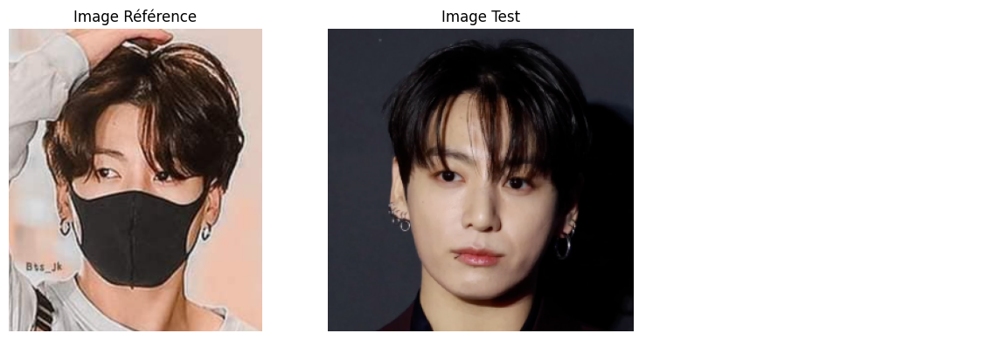


Référence : Screenshot 2026-04-23 105837.png
Comparée à: Screenshot 2026-04-23 174416.png
Similarité : 0.1587
Décision   : ❌ PERSONNE DIFFÉRENTE
----------------------------------------


/tmp/ipykernel_105/1706345773.py:85: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


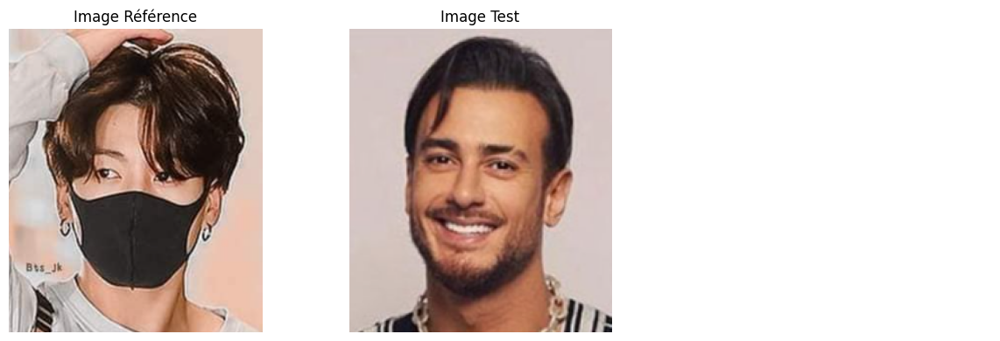

In [10]:
# ============================================================
# TESTER UNE IMAGE CONTRE LES AUTRES
# ============================================================

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

# ====================
# CHEMINS
# ====================

reference_image = "/kaggle/input/datasets/hibaelhamdani/test-and/Screenshot 2026-04-23 105837.png"

other_images = [
    "/kaggle/input/datasets/hibaelhamdani/test-and/Screenshot 2026-04-23 105750.png",
    "/kaggle/input/datasets/hibaelhamdani/test-and/Screenshot 2026-04-23 174416.png"
]

# ====================
# CALCUL EMBEDDING IMAGE RÉFÉRENCE
# ====================

with torch.no_grad():
    ref_img = Image.open(reference_image).convert("RGB")
    ref_tensor = transform(ref_img).unsqueeze(0).to(DEVICE)
    ref_embedding = F.normalize(model(ref_tensor), dim=1)

print("\n==============================")
print("RÉSULTATS COMPARAISON")
print("==============================\n")

# ====================
# COMPARAISON
# ====================

for img_path in other_images:

    with torch.no_grad():
        img = Image.open(img_path).convert("RGB")
        tensor = transform(img).unsqueeze(0).to(DEVICE)
        embedding = F.normalize(model(tensor), dim=1)

        similarity = F.cosine_similarity(ref_embedding, embedding).item()

    same_person = similarity >= THRESHOLD
    label = "✅ MÊME PERSONNE" if same_person else "❌ PERSONNE DIFFÉRENTE"

    print(f"\nRéférence : {reference_image.split('/')[-1]}")
    print(f"Comparée à: {img_path.split('/')[-1]}")
    print(f"Similarité : {similarity:.4f}")
    print(f"Décision   : {label}")
    print("-" * 40)

    # Affichage visuel
    fig, axes = plt.subplots(1, 3, figsize=(12,4))

    axes[0].imshow(ref_img)
    axes[0].set_title("Image Référence")
    axes[0].axis('off')

    axes[1].imshow(img)
    axes[1].set_title("Image Test")
    axes[1].axis('off')

    color = "green" if same_person else "red"

    axes[2].set_facecolor(color)
    axes[2].text(0.5, 0.6, label,
                 ha='center', va='center',
                 fontsize=14, fontweight='bold',
                 color='white',
                 transform=axes[2].transAxes)

    axes[2].text(0.5, 0.4,
                 f"Similarity : {similarity:.4f}",
                 ha='center', va='center',
                 fontsize=12,
                 color='white',
                 transform=axes[2].transAxes)

    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

fusionner les deux datasets.

In [1]:
import os
import shutil
from IPython.display import FileLink

# ==============================
#  CHEMINS DES DATASETS
# ==============================

DATASET1 = "/kaggle/input/datasets/hibaelhamdani/data-dl/Unified_Dataset"
DATASET2 = "/kaggle/input/datasets/hibaelhamdani/data-augmentation"

OUTPUT = "/kaggle/working/GLOBAL_DATASET"

# ==============================
#  CRÉER DOSSIER GLOBAL
# ==============================

if os.path.exists(OUTPUT):
    shutil.rmtree(OUTPUT)

os.makedirs(OUTPUT, exist_ok=True)

# ==============================
#  FONCTION COPIE IMAGES
# ==============================

def copy_images(src_folder, dst_folder):
    if not os.path.exists(src_folder):
        return 0

    os.makedirs(dst_folder, exist_ok=True)
    count = 0

    for img in os.listdir(src_folder):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            src = os.path.join(src_folder, img)
            dst = os.path.join(dst_folder, img)

            # éviter écrasement si même nom
            if os.path.exists(dst):
                base, ext = os.path.splitext(img)
                dst = os.path.join(dst_folder, base + "_copy" + ext)

            shutil.copy(src, dst)
            count += 1

    return count

# ==============================
#  FUSION DATASET 1
# ==============================

print("Fusion Dataset 1...")

for person in os.listdir(DATASET1):

    person_path = os.path.join(DATASET1, person)
    if not os.path.isdir(person_path):
        continue

    out_person = os.path.join(OUTPUT, person)
    masked_out = os.path.join(out_person, "masked")
    non_masked_out = os.path.join(out_person, "non_masked")

    copy_images(os.path.join(person_path, "masked"), masked_out)
    copy_images(os.path.join(person_path, "non_masked"), non_masked_out)

# ==============================
#  FUSION DATASET 2
# ==============================

print("Fusion Dataset 2...")

for person in os.listdir(DATASET2):

    person_path = os.path.join(DATASET2, person)
    if not os.path.isdir(person_path):
        continue

    out_person = os.path.join(OUTPUT, person)
    masked_out = os.path.join(out_person, "masked")
    non_masked_out = os.path.join(out_person, "non_masked")

    # Dataset2 utilise mask / no_mask
    copy_images(os.path.join(person_path, "mask"), masked_out)
    copy_images(os.path.join(person_path, "no_mask"), non_masked_out)

# ==============================
#  SUPPRIMER PERSONNES INVALIDES
# ==============================

print("Nettoyage des personnes invalides...")

valid_persons = 0
removed_persons = 0

for person in os.listdir(OUTPUT):

    person_path = os.path.join(OUTPUT, person)
    masked_path = os.path.join(person_path, "masked")
    non_masked_path = os.path.join(person_path, "non_masked")

    masked_imgs = os.listdir(masked_path) if os.path.exists(masked_path) else []
    non_masked_imgs = os.listdir(non_masked_path) if os.path.exists(non_masked_path) else []

    if len(masked_imgs) == 0 or len(non_masked_imgs) == 0:
        shutil.rmtree(person_path)
        removed_persons += 1
    else:
        valid_persons += 1

print(f" Personnes valides : {valid_persons}")
print(f" Personnes supprimées : {removed_persons}")

# ==============================
#  CRÉER ZIP FINAL
# ==============================

print("Compression du dataset...")

zip_path = shutil.make_archive(
    base_name="/kaggle/working/GLOBAL_DATASET",
    format="zip",
    root_dir="/kaggle/working",
    base_dir="GLOBAL_DATASET"
)

print(" ZIP créé :", zip_path)

# ==============================
# ✅ LIEN DE TÉLÉCHARGEMENT
# ==============================

display(FileLink(zip_path))

Fusion Dataset 1...
Fusion Dataset 2...
Nettoyage des personnes invalides...
 Personnes valides : 868
 Personnes supprimées : 0
Compression du dataset...
 ZIP créé : /kaggle/working/GLOBAL_DATASET.zip


/kaggle/working/GLOBAL_DATASET.zip

**test 2 avec data augmentation**

Backbone = un réseau de neurones profond complet (MobileNetV3) qui permet de transformer Image → vecteur de caractéristiques (features)

le probleme de mobilenetv3 est que il est entrainer sur plusieur données visage chien chat objet 

la solution pour réduire et garder juste les features important est 


Projection Head : petites couches linéaires
permet de réduire l’espace du vecteur pour garder les features utiles  
il apprend avec triplet loss pour garder juste essentiel


et aussi sont role :
Construire un espace où :

Les embeddings des mêmes personnes sont proches
Les embeddings des personnes différentes sont éloignés

In [ ]:
# ============================================================
# MASKED FACE VERIFICATION — MobileNetV3 + Semi-Hard Triplet Loss
# GPU OPTIMIZED + FULL BIOMETRIC METRICS
# ============================================================

import os, random, time, shutil, json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score
from IPython.display import FileLink

# =====================
# 1️⃣  CONFIG
# =====================
ROOT = "/kaggle/input/datasets/hibaelhamdani/data-final-augmenter/GLOBAL_DATASET"

IMG_SIZE    = 160
BATCH_SIZE  = 64        # ⬆️ plus grand batch = plus de candidats négatifs
EPOCHS      = 50
LR          = 3e-4
EMBED_DIM   = 256
MARGIN      = 0.3
NUM_WORKERS = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print("Device:", DEVICE)

# =====================
# 2️⃣  SPLIT PAR PERSONNE
# =====================
persons = [p for p in os.listdir(ROOT) if os.path.isdir(os.path.join(ROOT, p))]
random.shuffle(persons)

n = len(persons)
train_persons = persons[:int(0.70 * n)]
val_persons   = persons[int(0.70 * n):int(0.85 * n)]
test_persons  = persons[int(0.85 * n):]

print(f"Train: {len(train_persons)} | Val: {len(val_persons)} | Test: {len(test_persons)}")

# =====================
# 3️⃣  TRANSFORMS
# =====================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# =====================
# 4️⃣  DATASET PAIRES (pour semi-hard mining)
#      On charge des lots d'images par personne,
#      le mining se fait DANS le forward pass.
# =====================
class PairDataset(Dataset):
    """
    Retourne (image, label_int) — pas de triplets pré-formés.
    Le collateur assemble des batchs équilibrés (N personnes × K images).
    Semi-hard mining est fait à l'intérieur de la loss.
    """
    def __init__(self, root, persons, transform=None):
        self.root      = root
        self.transform = transform
        self.samples   = []   # list of (path, person_idx)
        self.labels    = []

        for idx, p in enumerate(persons):
            for typ in ["masked", "non_masked"]:
                folder = os.path.join(root, p, typ)
                if not os.path.isdir(folder):
                    continue
                for f in os.listdir(folder):
                    if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.samples.append((os.path.join(folder, f), idx))
                        self.labels.append(idx)

        print(f"  Dataset: {len(self.samples)} images, {len(persons)} personnes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# =====================
# 5️⃣  SEMI-HARD TRIPLET LOSS (en ligne)
# =====================
def semi_hard_triplet_loss(embeddings, labels, margin=0.3):
    """
    Semi-Hard Mining en ligne :
      Pour chaque ancre i et positif p (même label) :
        cherche un négatif n tel que
          d(a,p) < d(a,n) < d(a,p) + margin
      Si aucun semi-hard trouvé → prend le négatif le plus difficile
      (hard negative mining de repli).

    Args:
        embeddings : (B, D) — normalisés L2
        labels     : (B,)   — entiers

    Returns:
        scalar loss
    """
    B = embeddings.size(0)

    # Matrice de distances euclidiennes (B × B)
    dist = torch.cdist(embeddings, embeddings, p=2)   # (B, B)

    labels = labels.view(-1)
    loss_vals = []

    for i in range(B):
        # Masques positifs et négatifs pour l'ancre i
        pos_mask = (labels == labels[i])
        pos_mask[i] = False                           # exclure soi-même
        neg_mask = (labels != labels[i])

        if pos_mask.sum() == 0 or neg_mask.sum() == 0:
            continue

        # Distance anchor-positive : prend le plus DIFFICILE (max)
        d_ap = dist[i][pos_mask].max()

        d_neg = dist[i][neg_mask]   # distances anchor-négatifs

        # Condition semi-hard : d_ap < d_an < d_ap + margin
        semi_hard_mask = (d_neg > d_ap) & (d_neg < d_ap + margin)

        if semi_hard_mask.sum() > 0:
            # Parmi les semi-hard, prend le plus proche (le plus difficile)
            d_an = d_neg[semi_hard_mask].min()
        else:
            # Repli : hard negative (le négatif le plus proche, même s'il viole)
            d_an = d_neg.min()

        loss = F.relu(d_ap - d_an + margin)
        loss_vals.append(loss)

    if len(loss_vals) == 0:
        return embeddings.sum() * 0   # gradient 0 propre

    return torch.stack(loss_vals).mean()


# =====================
# 6️⃣  SAMPLER ÉQUILIBRÉ (P personnes × K images par batch)
# =====================
class PKSampler(torch.utils.data.Sampler):
    """
    Batch de taille P*K :
      P personnes tirées aléatoirement,
      K images par personne.
    Garantit au moins 1 positif par ancre dans le batch.
    """
    def __init__(self, labels, P=16, K=4):
        self.labels = np.array(labels)
        self.P = P
        self.K = K
        # index par personne
        self.person_to_idxs = {}
        for idx, lbl in enumerate(self.labels):
            self.person_to_idxs.setdefault(lbl, []).append(idx)
        self.valid_persons = [p for p, idxs in self.person_to_idxs.items()
                              if len(idxs) >= K]
        print(f"  PKSampler: {len(self.valid_persons)} personnes valides "
              f"(P={P}, K={K}, batch={P*K})")

    def __iter__(self):
        batch = []
        while True:
            chosen = random.sample(self.valid_persons,
                                   min(self.P, len(self.valid_persons)))
            for p in chosen:
                idxs = random.choices(self.person_to_idxs[p], k=self.K)
                batch.extend(idxs)
            if len(batch) >= self.P * self.K:
                yield from batch
                return

    def __len__(self):
        n_batches = len(self.valid_persons) // self.P
        return n_batches * self.P * self.K


# =====================
# 7️⃣  DATALOADER
# =====================
P, K = 16, 4   # 16 personnes × 4 images → batch = 64

train_ds = PairDataset(ROOT, train_persons, train_tf)
val_ds   = PairDataset(ROOT, val_persons,   val_tf)

train_sampler = PKSampler(train_ds.labels, P=P, K=K)

train_loader = DataLoader(
    train_ds,
    batch_sampler=None,
    batch_size=P * K,
    sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

# =====================
# 8️⃣  MODEL
# =====================
class FaceModel(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        base = models.mobilenet_v3_large(pretrained=True)
        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 512),
            nn.BatchNorm1d(512),
            nn.Hardswish(),
            nn.Dropout(0.4),
            nn.Linear(512, embed_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)   # embeddings L2-normalisés

model = FaceModel(EMBED_DIM).to(DEVICE)

# =====================
# 9️⃣  OPTIM + SCHEDULER
# =====================
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.cuda.amp.GradScaler()

# =====================
# 🔟  TRAIN LOOP
# =====================
best_val_loss = 1e9
history = {"train_loss": [], "val_loss": []}

for epoch in range(EPOCHS):
    # ── TRAIN ──────────────────────────────────────────────
    model.train()
    train_loss, n_batches = 0.0, 0

    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            embs = model(imgs)
            loss = semi_hard_triplet_loss(embs, labels, MARGIN)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        n_batches  += 1

    avg_train = train_loss / max(n_batches, 1)

    # ── VALIDATION ─────────────────────────────────────────
    model.eval()
    val_loss, v_batches = 0.0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                embs = model(imgs)
                loss = semi_hard_triplet_loss(embs, labels, MARGIN)
            val_loss  += loss.item()
            v_batches += 1

    avg_val = val_loss / max(v_batches, 1)
    scheduler.step()

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
          f"Train {avg_train:.4f} | Val {avg_val:.4f}"
          + (" ✅ best" if avg_val < best_val_loss else ""))

    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), "/kaggle/working/best_model.pt")

# =====================
# 1️⃣1️⃣  ÉVALUATION BIOMÉTRIQUE
# =====================
# Charge le meilleur modèle
model.load_state_dict(torch.load("/kaggle/working/best_model.pt"))
model.eval()

def build_pairs(persons, n_pairs=5000):
    """
    Construit n_pairs paires positives + n_pairs paires négatives.
    Retourne scores (similarité cosinus) et labels.
    """
    scores, labels_out = [], []

    valid = [p for p in persons
             if os.path.isdir(os.path.join(ROOT, p, "masked"))
             and os.path.isdir(os.path.join(ROOT, p, "non_masked"))]

    with torch.no_grad():
        for _ in range(n_pairs):
            p = random.choice(valid)

            def pick(person, typ):
                folder = os.path.join(ROOT, person, typ)
                fname  = random.choice(os.listdir(folder))
                img    = Image.open(os.path.join(folder, fname)).convert("RGB")
                return model(val_tf(img).unsqueeze(0).to(DEVICE))

            e1 = pick(p, "non_masked")

            # Paire POSITIVE : même personne, image masquée
            e2 = pick(p, "masked")
            scores.append(F.cosine_similarity(e1, e2).item())
            labels_out.append(1)

            # Paire NÉGATIVE : personne différente
            p2   = random.choice([x for x in valid if x != p])
            typ2 = random.choice(["masked", "non_masked"])
            e3   = pick(p2, typ2)
            scores.append(F.cosine_similarity(e1, e3).item())
            labels_out.append(0)

    return np.array(scores), np.array(labels_out)


scores, labels_eval = build_pairs(test_persons, n_pairs=5000)

auc = roc_auc_score(labels_eval, scores)
fpr, tpr, thresholds = roc_curve(labels_eval, scores)

# EER
fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = fpr[eer_idx]

def tar_at_far(target):
    idx = np.nanargmin(np.abs(fpr - target))
    return float(tpr[idx])

metrics = {
    "AUC":              float(auc),
    "EER":              float(eer),
    "EER_threshold":    float(thresholds[eer_idx]),
    "TAR@EER":          float(tpr[eer_idx]),
    "TAR@FAR=0.0001":   tar_at_far(1e-4),
    "TAR@FAR=0.001":    tar_at_far(1e-3),
    "TAR@FAR=0.01":     tar_at_far(1e-2),
    "TAR@FAR=0.1":      tar_at_far(0.1),
}

print("\n📊 RÉSULTATS BIOMÉTRIQUES")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

# =====================
# 1️⃣2️⃣  SAUVEGARDE
# =====================
torch.save(model.state_dict(), "/kaggle/working/final_model.pt")

with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f, indent=4)

shutil.make_archive("/kaggle/working/RESULTS", "zip", "/kaggle/working")
display(FileLink("/kaggle/working/RESULTS.zip"))

Device: cuda
Train: 607 | Val: 130 | Test: 131
  Dataset: 9593 images, 607 personnes


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Large_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  Dataset: 2141 images, 130 personnes
  PKSampler: 607 personnes valides (P=16, K=4, batch=64)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 187MB/s]
/tmp/ipykernel_57/2793840671.py:268: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()
/tmp/ipykernel_57/2793840671.py:286: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_57/2793840671.py:309: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch   1/50 | Train 0.2955 | Val 0.2901 ✅ best
Epoch   2/50 | Train 0.2988 | Val 0.2884 ✅ best
Epoch   3/50 | Train 0.3043 | Val 0.2886
Epoch   4/50 | Train 0.3049 | Val 0.2844 ✅ best
Epoch   5/50 | Train 0.3002 | Val 0.2892
Epoch   6/50 | Train 0.3010 | Val 0.2909
Epoch   7/50 | Train 0.3105 | Val 0.2858
Epoch   8/50 | Train 0.2918 | Val 0.2844 ✅ best
Epoch   9/50 | Train 0.2913 | Val 0.2827 ✅ best
Epoch  10/50 | Train 0.2888 | Val 0.2810 ✅ best
Epoch  11/50 | Train 0.2901 | Val 0.2894
Epoch  12/50 | Train 0.2893 | Val 0.2818
Epoch  13/50 | Train 0.2819 | Val 0.2811
Epoch  14/50 | Train 0.2848 | Val 0.2816
Epoch  15/50 | Train 0.2879 | Val 0.2852
Epoch  16/50 | Train 0.2979 | Val 0.2847
Epoch  17/50 | Train 0.2906 | Val 0.2812
Epoch  18/50 | Train 0.2885 | Val 0.2823
Epoch  19/50 | Train 0.2898 | Val 0.2791 ✅ best
Epoch  20/50 | Train 0.3140 | Val 0.2818
Epoch  21/50 | Train 0.2827 | Val 0.2854
Epoch  22/50 | Train 0.2884 | Val 0.2835
Epoch  23/50 | Train 0.2787 | Val 0.2809
Epoch  2

Les performances obtenues sont faibles et insuffisantes pour un système de vérification faciale fiable.

AUC = 0.6553 : proche du hasard (0.5). Le modèle discrimine mal les paires positives et négatives.
EER = 0.3874 (≈ 39%) : taux d’erreur très élevé. Un bon système biométrique vise généralement < 10%.
TAR@FAR faibles (≈ 0) : lorsque le système est configuré pour être sécurisé (faible FAR), il rejette presque tous les utilisateurs légitimes

In [2]:
# ============================================================
# MASKED FACE VERIFICATION
# Fine-tuning Progressif + Batch Hard Triplet Loss
# ============================================================

import os, random, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score
from collections import defaultdict
from IPython.display import FileLink

# =====================
# 1️⃣ CONFIG
# =====================
ROOT        = "/kaggle/input/datasets/hibaelhamdani/data-final-augmenter/GLOBAL_DATASET"
IMG_SIZE    = 224
EPOCHS      = 40
WARMUP_EPOCHS = 5        # epochs avec backbone gelé
LR          = 1e-3
LR_BACKBONE = 1e-4       # LR plus petit pour MobileNet en phase 2
EMBED_DIM   = 512
MARGIN      = 0.5
P           = 18         # personnes par batch
K           = 6          # images par personne
BATCH_SIZE  = P * K      # = 108
NUM_WORKERS = 4
PATIENCE    = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Device: {DEVICE}")

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# =====================
# 2️⃣ SPLIT
# =====================
persons = sorted([
    p for p in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, p))
])

# Garder seulement les personnes avec au moins 2 masked + 2 non_masked
def is_valid(person):
    counts = {}
    for typ in ["masked", "non_masked"]:
        folder = os.path.join(ROOT, person, typ)
        if os.path.isdir(folder):
            counts[typ] = len([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))
            ])
        else:
            counts[typ] = 0
    return counts.get("masked", 0) >= 2 and counts.get("non_masked", 0) >= 2

valid_persons = [p for p in persons if is_valid(p)]
print(f"Personnes valides : {len(valid_persons)}")

random.shuffle(valid_persons)
n = len(valid_persons)
train_persons = valid_persons[:int(0.70 * n)]
val_persons   = valid_persons[int(0.70 * n):int(0.85 * n)]
test_persons  = valid_persons[int(0.85 * n):]
print(f"Train: {len(train_persons)} | Val: {len(val_persons)} | Test: {len(test_persons)}")

# =====================
# 3️⃣ TRANSFORMS
# =====================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# =====================
# 4️⃣ DATASET
# =====================
class FaceDataset(Dataset):
    def __init__(self, root, persons, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for idx, p in enumerate(persons):
            for typ in ["masked", "non_masked"]:
                folder = os.path.join(root, p, typ)
                if not os.path.isdir(folder):
                    continue
                for f in os.listdir(folder):
                    if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.samples.append((os.path.join(folder, f), idx))
                        self.labels.append(idx)

        print(f"  Dataset: {len(self.samples)} images, {len(persons)} personnes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# =====================
# 5️⃣ PK SAMPLER
# =====================
class PKSampler(Sampler):
    def __init__(self, labels, P=18, K=6):
        self.labels = np.array(labels)
        self.P = P
        self.K = K

        self.label_to_idxs = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            self.label_to_idxs[lbl].append(i)

        # Personnes avec au moins K images
        self.valid_labels = [
            lbl for lbl, idxs in self.label_to_idxs.items()
            if len(idxs) >= K
        ]

        self.n_batches = len(self.labels) // (P * K)
        print(f"  PKSampler: {len(self.valid_labels)} personnes | "
              f"P={P}, K={K} | {self.n_batches} batches/epoch")

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen = random.sample(
                self.valid_labels,
                min(self.P, len(self.valid_labels))
            )
            for lbl in chosen:
                idxs = random.choices(self.label_to_idxs[lbl], k=self.K)
                batch.extend(idxs)
            yield batch

    def __len__(self):
        return self.n_batches

# =====================
# 6️⃣ DATALOADERS
# =====================
train_ds = FaceDataset(ROOT, train_persons, train_tf)
val_ds   = FaceDataset(ROOT, val_persons,   val_tf)

train_sampler = PKSampler(train_ds.labels, P=P, K=K)
val_sampler   = PKSampler(val_ds.labels,
                          P=min(P, len(val_persons) // 2),
                          K=K)

train_loader = DataLoader(
    train_ds,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# =====================
# 7️⃣ MODÈLE
# =====================
class FaceModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        base = models.mobilenet_v3_large(weights=weights)

        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

        # Initialisation des couches linéaires
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)   # L2 normalisé

    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
        print("  Backbone GELÉ")

    def unfreeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = True
        print("  Backbone DÉGELÉ")

model = FaceModel(EMBED_DIM).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
print(f"Paramètres total: {total:,}")

# =====================
# 8️⃣ BATCH HARD TRIPLET LOSS
# =====================
def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    """
    Pour chaque ancre :
      - Positif  = image même personne LA PLUS LOIN (hard positive)
      - Négatif  = image autre personne LA PLUS PROCHE (hard negative)
    Tous les triplets du batch sont utilisés → gradient toujours fort
    """
    B = embeddings.size(0)

    # ── Matrice de distances euclidiennes (B × B) ──────────────
    dist = torch.cdist(embeddings, embeddings, p=2)

    labels = labels.view(-1)

    # Masques
    same    = labels.unsqueeze(0) == labels.unsqueeze(1)   # (B,B) bool
    eye     = torch.eye(B, dtype=torch.bool, device=DEVICE)
    pos_mask = same & ~eye     # même personne, pas soi-même
    neg_mask = ~same           # personne différente

    # ── Hard Positive : distance MAX parmi les positifs ────────
    # On met 0 là où c'est pas un positif, puis on prend le max
    dist_ap = (dist * pos_mask.float()).max(dim=1)[0]

    # ── Hard Negative : distance MIN parmi les négatifs ────────
    # On met +inf là où c'est pas un négatif, puis on prend le min
    inf_mask = (~neg_mask).float() * 1e9
    dist_an  = (dist + inf_mask).min(dim=1)[0]

    # ── Garder seulement les ancres avec positifs ET négatifs ──
    valid = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    if valid.sum() == 0:
        return embeddings.sum() * 0, 0.0

    dist_ap = dist_ap[valid]
    dist_an = dist_an[valid]

    # ── Loss triplet ────────────────────────────────────────────
    losses = F.relu(dist_ap - dist_an + margin)

    # % de triplets actifs (loss > 0) → indicateur de difficulté
    active_frac = (losses > 0).float().mean().item()

    return losses.mean(), active_frac

# =====================
# 9️⃣ ENTRAÎNEMENT
# =====================

# ── PHASE 1 : Backbone gelé ─────────────────────────────────
model.freeze_backbone()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS, eta_min=1e-5)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss    = float('inf')
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "active_frac": [], "phase": []}

print("\n" + "="*60)
print("PHASE 1 — Backbone gelé (warmup)")
print("="*60)

for epoch in range(EPOCHS):

    # ── Passage Phase 1 → Phase 2 ───────────────────────────
    if epoch == WARMUP_EPOCHS:
        model.unfreeze_backbone()

        # Deux learning rates : backbone petit, tête grand
        optimizer = torch.optim.AdamW([
            {'params': model.features.parameters(), 'lr': LR_BACKBONE},
            {'params': model.head.parameters(),     'lr': LR}
        ], weight_decay=1e-4)

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - WARMUP_EPOCHS,
            eta_min=1e-6
        )

        print("\n" + "="*60)
        print(f"PHASE 2 — Fine-tuning complet")
        print(f"  Backbone LR = {LR_BACKBONE} | Tête LR = {LR}")
        print("="*60)

    # ── TRAIN ────────────────────────────────────────────────
    model.train()
    train_loss_sum  = 0.0
    active_frac_sum = 0.0
    n_batches       = 0

    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            embs         = model(imgs)
            loss, active = batch_hard_triplet_loss(embs, labels, MARGIN)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum  += loss.item()
        active_frac_sum += active
        n_batches       += 1

    avg_train  = train_loss_sum  / max(n_batches, 1)
    avg_active = active_frac_sum / max(n_batches, 1)

    # ── VALIDATION ───────────────────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    v_batches    = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                embs         = model(imgs)
                loss, _      = batch_hard_triplet_loss(embs, labels, MARGIN)
            val_loss_sum += loss.item()
            v_batches    += 1

    avg_val = val_loss_sum / max(v_batches, 1)
    scheduler.step()

    phase = "warmup" if epoch < WARMUP_EPOCHS else "finetune"
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["active_frac"].append(avg_active)
    history["phase"].append(phase)

    improved = avg_val < best_val_loss
    if improved:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': best_val_loss,
        }, "/kaggle/working/best_model.pt")
    else:
        patience_counter += 1

    status = "✅ best" if improved else f"⏳ ({patience_counter}/{PATIENCE})"
    cur_lr = optimizer.param_groups[-1]['lr']

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
          f"[{phase:8s}] | "
          f"Train {avg_train:.4f} | "
          f"Val {avg_val:.4f} | "
          f"Active {avg_active:.1%} | "
          f"LR {cur_lr:.2e} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\n Early stopping epoch {epoch+1}")
        break

print(f"\n Meilleure val loss : {best_val_loss:.4f}")

# =====================
# 🔟 ÉVALUATION BIOMÉTRIQUE
# =====================
checkpoint = torch.load("/kaggle/working/best_model.pt")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"\nMeilleur modèle : epoch {checkpoint['epoch']+1}")

def get_embedding(img_path):
    img    = Image.open(img_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(tensor)
    return emb.cpu()

def build_test_pairs(persons, n_pairs=3000):
    """
    4 types de paires :
    - Positif : non_masked vs masked     (cas critique)
    - Positif : masked vs masked
    - Négatif : personnes différentes (toutes combinaisons)
    """
    scores, labels_out = [], []

    valid = [
        p for p in persons
        if os.path.isdir(os.path.join(ROOT, p, "masked"))
        and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
    ]
    print(f"  Personnes test valides : {len(valid)}")

    def rand_img(person, typ):
        folder = os.path.join(ROOT, person, typ)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg','.png','.jpeg'))]
        return os.path.join(folder, random.choice(files))

    for _ in range(n_pairs):
        p = random.choice(valid)

        # Positif 1 : non_masked → masked (même personne)
        e1 = get_embedding(rand_img(p, "non_masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(1)

        # Positif 2 : masked → masked (même personne)
        e1 = get_embedding(rand_img(p, "masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(1)

        # Négatif : deux personnes différentes
        p2   = random.choice([x for x in valid if x != p])
        t1   = random.choice(["masked", "non_masked"])
        t2   = random.choice(["masked", "non_masked"])
        e1   = get_embedding(rand_img(p,  t1))
        e2   = get_embedding(rand_img(p2, t2))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(0)

    return np.array(scores), np.array(labels_out)

print("\n Construction des paires de test...")
scores, labels_eval = build_test_pairs(test_persons, n_pairs=3000)
print(f"  Total : {len(scores)} paires | "
      f"Positifs : {labels_eval.sum()} | "
      f"Négatifs : {(1-labels_eval).sum()}")

# ── Métriques ────────────────────────────────────────────────
auc = roc_auc_score(labels_eval, scores)
fpr, tpr, thresholds = roc_curve(labels_eval, scores)

fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = float(fpr[eer_idx])

def tar_at_far(target):
    idx = np.searchsorted(fpr, target, side='right') - 1
    idx = max(0, min(idx, len(tpr) - 1))
    return float(tpr[idx])

metrics = {
    "AUC"           : float(auc),
    "EER"           : float(eer),
    "EER_threshold" : float(thresholds[eer_idx]),
    "TAR@EER"       : float(tpr[eer_idx]),
    "TAR@FAR=0.0001": tar_at_far(1e-4),
    "TAR@FAR=0.001" : tar_at_far(1e-3),
    "TAR@FAR=0.01"  : tar_at_far(1e-2),
    "TAR@FAR=0.1"   : tar_at_far(0.1),
}

print("\n RÉSULTATS BIOMÉTRIQUES")
print("-" * 45)
for k, v in metrics.items():
    if k == "AUC":
        q = "🟢" if v > 0.90 else "🟡" if v > 0.80 else "🔴"
    elif k == "EER":
        q = "🟢" if v < 0.10 else "🟡" if v < 0.20 else "🔴"
    else:
        q = ""
    print(f"  {k:<22}: {v:.4f} {q}")

# =====================
# SAUVEGARDE
# =====================
torch.save(model.state_dict(), "/kaggle/working/final_model.pt")

with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f, indent=4)

shutil.make_archive("/kaggle/working/RESULTS", "zip", "/kaggle/working")
display(FileLink("/kaggle/working/RESULTS.zip"))
print("\n Sauvegarde terminée !")

Device: cuda
Personnes valides : 745
Train: 521 | Val: 112 | Test: 112
  Dataset: 9416 images, 521 personnes
  Dataset: 1905 images, 112 personnes
  PKSampler: 521 personnes | P=18, K=6 | 87 batches/epoch
  PKSampler: 112 personnes | P=18, K=6 | 17 batches/epoch
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 92.0MB/s]


Paramètres total: 4,483,888
  Backbone GELÉ

PHASE 1 — Backbone gelé (warmup)
Epoch   1/40 | [warmup  ] | Train 0.6506 | Val 0.8052 | Active 100.0% | LR 9.05e-04 | ✅ best
Epoch   2/40 | [warmup  ] | Train 0.6414 | Val 0.7474 | Active 100.0% | LR 6.58e-04 | ✅ best
Epoch   3/40 | [warmup  ] | Train 0.6338 | Val 0.6998 | Active 100.0% | LR 3.52e-04 | ✅ best
Epoch   4/40 | [warmup  ] | Train 0.6315 | Val 0.6809 | Active 100.0% | LR 1.05e-04 | ✅ best
Epoch   5/40 | [warmup  ] | Train 0.6255 | Val 0.6838 | Active 100.0% | LR 1.00e-05 | ⏳ (1/10)
  Backbone DÉGELÉ

PHASE 2 — Fine-tuning complet
  Backbone LR = 0.0001 | Tête LR = 0.001
Epoch   6/40 | [finetune] | Train 0.6344 | Val 0.6809 | Active 100.0% | LR 9.98e-04 | ⏳ (2/10)
Epoch   7/40 | [finetune] | Train 0.6311 | Val 0.6843 | Active 100.0% | LR 9.92e-04 | ⏳ (3/10)
Epoch   8/40 | [finetune] | Train 0.6246 | Val 0.6636 | Active 100.0% | LR 9.82e-04 | ✅ best
Epoch   9/40 | [finetune] | Train 0.6193 | Val 0.6686 | Active 100.0% | LR 9.68e-0

OSError: [Errno 28] No space left on device

In [3]:
import os
import shutil
import torch
from IPython.display import FileLink

# =====================
# ÉTAPE 1 : Voir ce qui prend de la place
# =====================
print("=== Espace utilisé dans /kaggle/working ===")
for f in os.listdir("/kaggle/working"):
    path = os.path.join("/kaggle/working", f)
    size = os.path.getsize(path) / (1024**2)  # en MB
    print(f"  {f:40s} : {size:.1f} MB")

# =====================
# ÉTAPE 2 : Supprimer les fichiers inutiles
# =====================

# Supprimer l'ancien ZIP raté s'il existe
if os.path.exists("/kaggle/working/RESULTS.zip"):
    os.remove("/kaggle/working/RESULTS.zip")
    print("ZIP raté supprimé")

# Supprimer le modèle intermédiaire (on garde seulement le final)
# (best_model.pt et final_model.pt sont pareil)
if os.path.exists("/kaggle/working/best_model.pt"):
    os.remove("/kaggle/working/best_model.pt")
    print("best_model.pt supprimé")

print("Espace libéré !")

# =====================
# ÉTAPE 3 : Sauvegarder SEULEMENT les fichiers importants
# =====================

# Sauvegarder seulement le modèle final
torch.save(model.state_dict(), "/kaggle/working/final_model.pt")
print("Modèle sauvegardé")

# Sauvegarder les métriques
import json
with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
print("Métriques sauvegardées")

# Sauvegarder l'historique
with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f, indent=4)
print("Historique sauvegardé")

# =====================
# ÉTAPE 4 : Créer un ZIP seulement des fichiers importants
# =====================
# Au lieu de zipper tout /kaggle/working
# On zippe seulement les 3 fichiers importants

import zipfile

with zipfile.ZipFile("/kaggle/working/RESULTS.zip", "w",
                     compression=zipfile.ZIP_DEFLATED) as zf:
    zf.write("/kaggle/working/final_model.pt", "final_model.pt")
    zf.write("/kaggle/working/metrics.json",   "metrics.json")
    zf.write("/kaggle/working/history.json",   "history.json")

print("ZIP créé avec succès !")
display(FileLink("/kaggle/working/RESULTS.zip"))

=== Espace utilisé dans /kaggle/working ===
  .virtual_documents                       : 0.0 MB
  final_model.pt                           : 17.3 MB
  history.json                             : 0.0 MB
  metrics.json                             : 0.0 MB
  RESULTS.zip                              : 19935.8 MB
  best_model.pt                            : 17.3 MB
ZIP raté supprimé
best_model.pt supprimé
Espace libéré !
Modèle sauvegardé
Métriques sauvegardées
Historique sauvegardé
ZIP créé avec succès !


/kaggle/working/RESULTS.zip

In [9]:
from IPython.display import FileLink, display
import os

# Méthode Kaggle officielle
# Les fichiers dans /kaggle/working sont accessibles
# via l'onglet OUTPUT du notebook

print("📁 VOS FICHIERS SONT DISPONIBLES ICI :")
print("")
print("1. Regardez à DROITE de votre écran")
print("2. Cliquez sur l'onglet 'Output'")
print("3. Vous verrez tous vos fichiers")
print("4. Cliquez sur le fichier pour le télécharger")
print("")
print("Fichiers disponibles :")
for f in os.listdir("/kaggle/working"):
    if not f.startswith("."):
        path = os.path.join("/kaggle/working", f)
        size = os.path.getsize(path) / (1024**2)
        print(f"  → {f} ({size:.1f} MB)")

📁 VOS FICHIERS SONT DISPONIBLES ICI :

1. Regardez à DROITE de votre écran
2. Cliquez sur l'onglet 'Output'
3. Vous verrez tous vos fichiers
4. Cliquez sur le fichier pour le télécharger

Fichiers disponibles :
  → final_model.pt (17.3 MB)
  → history.json (0.0 MB)
  → metrics.json (0.0 MB)
  → RESULTS.zip (16.0 MB)


tester le modell sur les images

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 215MB/s]


Modele charge !
Personnes disponibles : 868

Calcul des prédictions en cours...

   PAIRES POSITIVES — MEME PERSONNE


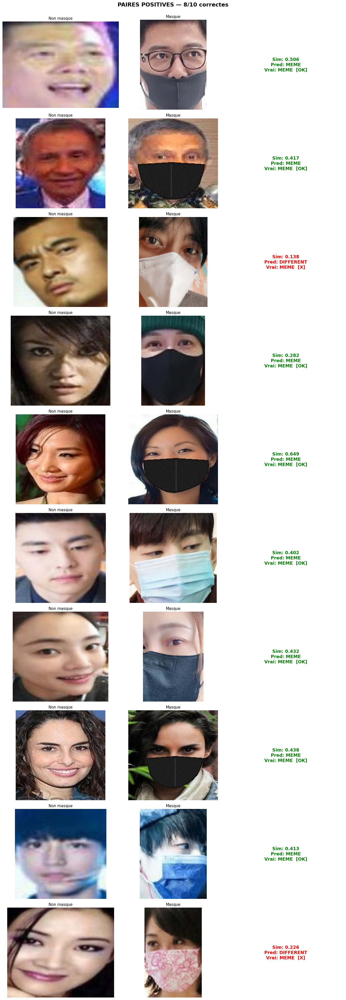


   PAIRES NEGATIVES — PERSONNES DIFFERENTES


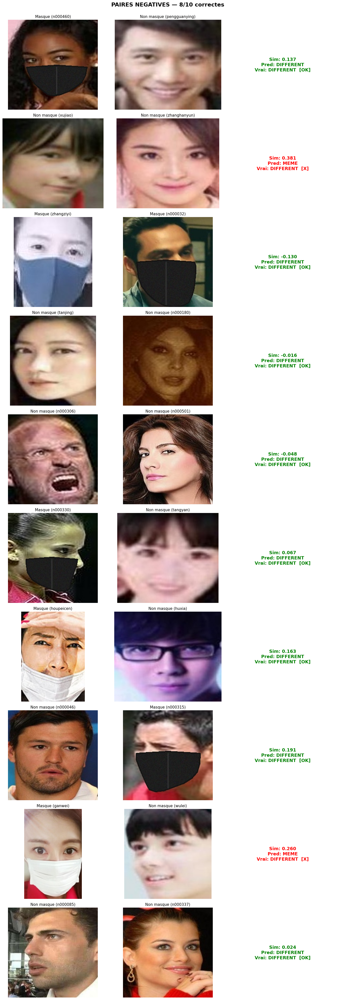


   RESUME DE PERFORMANCE

  Total tests effectues : 20
  Predictions correctes : 16
  Predictions erronees  : 4

  PRECISION GLOBALE     : 80.0%
  Precision positifs    : 80.0%
  Rappel (recall)       : 80.0%

  --- Matrice de confusion ---
  Vrais Positifs  (TP)  : 8/10
  Faux Negatifs   (FN)  : 2/10
  Vrais Negatifs  (TN)  : 8/10
  Faux Positifs   (FP)  : 2/10

  --- Statistiques scores ---
  Score moyen positifs  : 0.390
  Score moyen negatifs  : 0.103
  Separation des scores : 0.287

  Seuil utilise         : 0.2574


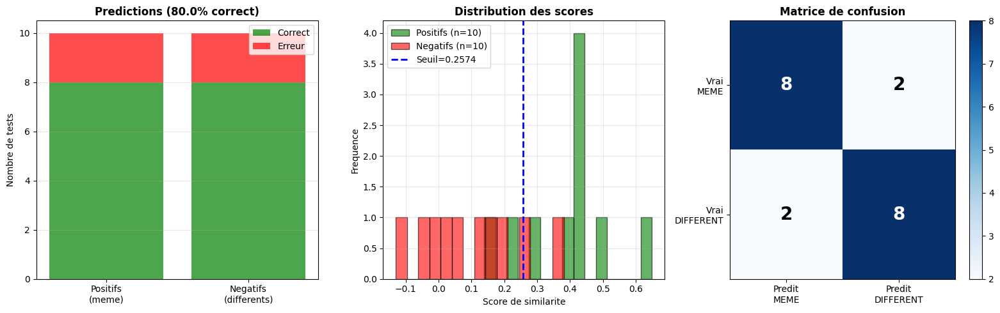

In [1]:
# ============================================================
# TEST VISUEL COMPLET — Évaluation Performance du Modèle
# ============================================================

import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np

# =====================
# CONFIG
# =====================
ROOT       = "/kaggle/input/datasets/hibaelhamdani/data-final-augmenter/GLOBAL_DATASET"
MODEL_PATH = "/kaggle/input/models/hibaelhamdani/mobilenetv3-maskedfacerecognition/pytorch/default/1/final_model.pt"
IMG_SIZE   = 224
EMBED_DIM  = 512
THRESHOLD  = 0.2574

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =====================
# MODÈLE
# =====================
class FaceModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        weights       = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        base          = models.mobilenet_v3_large(weights=weights)
        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)

model = FaceModel(EMBED_DIM).to(DEVICE)
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.eval()
print("Modele charge !")

# =====================
# TRANSFORM
# =====================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# =====================
# FONCTIONS
# =====================
def get_embedding(img_path):
    img    = Image.open(img_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(tensor)
    return emb

def comparer(photo1, photo2):
    emb1  = get_embedding(photo1)
    emb2  = get_embedding(photo2)
    score = F.cosine_similarity(emb1, emb2).item()
    meme  = score > THRESHOLD
    return meme, score

# =====================
# RÉCUPÉRER LES PERSONNES
# =====================
def get_personnes_valides():
    personnes = []
    for p in os.listdir(ROOT):
        masked     = os.path.join(ROOT, p, "masked")
        non_masked = os.path.join(ROOT, p, "non_masked")
        if (os.path.isdir(masked) and os.path.isdir(non_masked) and
                len(os.listdir(masked)) > 0 and
                len(os.listdir(non_masked)) > 0):
            personnes.append(p)
    return personnes

def img_aleatoire(personne, typ):
    dossier  = os.path.join(ROOT, personne, typ)
    fichiers = [f for f in os.listdir(dossier)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    return os.path.join(dossier, random.choice(fichiers))

# =====================
# AFFICHAGE EN GRILLE
# =====================
def afficher_grille(paires, titre_principal):
    """
    Affiche toutes les paires sur une seule grande figure
    
    Args:
        paires : liste de dicts avec 'photo1', 'photo2', 'label_vrai',
                 'type1', 'type2'
        titre_principal : titre de la figure
    """
    n = len(paires)

    # Grille : n lignes × 3 colonnes (photo1 | photo2 | résultat)
    fig, axes = plt.subplots(n, 3, figsize=(14, 4 * n))

    if n == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(titre_principal, fontsize=16, fontweight="bold", y=1.00)

    correct_total = 0

    for i, paire in enumerate(paires):
        photo1     = paire['photo1']
        photo2     = paire['photo2']
        label_vrai = paire['label_vrai']
        type1      = paire['type1']
        type2      = paire['type2']

        meme, score = comparer(photo1, photo2)
        correct     = (meme == label_vrai)
        correct_total += correct

        pred_text = "MEME" if meme else "DIFFERENT"
        vrai_text = "MEME" if label_vrai else "DIFFERENT"
        couleur   = "green" if correct else "red"
        symbole   = "OK" if correct else "X"

        # Photo 1
        img1 = Image.open(photo1).convert("RGB")
        axes[i, 0].imshow(img1)
        axes[i, 0].set_title(type1, fontsize=11)
        axes[i, 0].axis("off")

        # Photo 2
        img2 = Image.open(photo2).convert("RGB")
        axes[i, 1].imshow(img2)
        axes[i, 1].set_title(type2, fontsize=11)
        axes[i, 1].axis("off")

        # Résultat
        axes[i, 2].axis("off")
        texte = (f"Sim: {score:.3f}\n"
                 f"Pred: {pred_text}\n"
                 f"Vrai: {vrai_text}  [{symbole}]")
        axes[i, 2].text(0.5, 0.5, texte,
                        ha="center", va="center",
                        fontsize=13, fontweight="bold",
                        color=couleur,
                        transform=axes[i, 2].transAxes)

    plt.tight_layout()
    plt.show()

    return correct_total, n

# =====================
# ÉVALUATION COMPLÈTE
# =====================
def evaluation_complete(n_positifs=8, n_negatifs=8):
    """
    Évalue le modèle sur plusieurs paires positives et négatives
    et affiche un résumé complet de la performance
    """
    personnes = get_personnes_valides()
    print(f"Personnes disponibles : {len(personnes)}\n")

    # ── Préparer les paires POSITIVES ───────────────────────
    paires_pos = []
    for _ in range(n_positifs):
        p = random.choice(personnes)
        paires_pos.append({
            'photo1'    : img_aleatoire(p, "non_masked"),
            'photo2'    : img_aleatoire(p, "masked"),
            'label_vrai': True,
            'type1'     : "Non masque",
            'type2'     : "Masque",
            'personne'  : p,
        })

    # ── Préparer les paires NÉGATIVES ───────────────────────
    paires_neg = []
    for _ in range(n_negatifs):
        p1 = random.choice(personnes)
        p2 = random.choice([x for x in personnes if x != p1])
        t1 = random.choice(["masked", "non_masked"])
        t2 = random.choice(["masked", "non_masked"])

        label1 = "Non masque" if t1 == "non_masked" else "Masque"
        label2 = "Non masque" if t2 == "non_masked" else "Masque"

        paires_neg.append({
            'photo1'    : img_aleatoire(p1, t1),
            'photo2'    : img_aleatoire(p2, t2),
            'label_vrai': False,
            'type1'     : f"{label1} ({p1})",
            'type2'     : f"{label2} ({p2})",
            'personne'  : f"{p1} vs {p2}",
        })

    # ── Calculer les scores avant affichage ─────────────────
    print("Calcul des prédictions en cours...\n")

    scores_pos = []
    correct_pos = 0
    for paire in paires_pos:
        meme, score = comparer(paire['photo1'], paire['photo2'])
        scores_pos.append(score)
        if meme == paire['label_vrai']:
            correct_pos += 1

    scores_neg = []
    correct_neg = 0
    for paire in paires_neg:
        meme, score = comparer(paire['photo1'], paire['photo2'])
        scores_neg.append(score)
        if meme == paire['label_vrai']:
            correct_neg += 1

    # ── Afficher les paires POSITIVES ───────────────────────
    print("="*60)
    print("   PAIRES POSITIVES — MEME PERSONNE")
    print("="*60)
    afficher_grille(paires_pos,
                    f"PAIRES POSITIVES — {correct_pos}/{n_positifs} correctes")

    # ── Afficher les paires NÉGATIVES ───────────────────────
    print("\n" + "="*60)
    print("   PAIRES NEGATIVES — PERSONNES DIFFERENTES")
    print("="*60)
    afficher_grille(paires_neg,
                    f"PAIRES NEGATIVES — {correct_neg}/{n_negatifs} correctes")

    # ── Résumé Performance ──────────────────────────────────
    afficher_resume(scores_pos, scores_neg,
                    correct_pos, correct_neg,
                    n_positifs, n_negatifs)

# =====================
# RÉSUMÉ + GRAPHIQUES
# =====================
def afficher_resume(scores_pos, scores_neg,
                    correct_pos, correct_neg,
                    n_pos, n_neg):
    """
    Affiche un résumé textuel et graphique de la performance
    """
    total          = n_pos + n_neg
    correct_total  = correct_pos + correct_neg
    precision      = correct_total / total * 100

    # Métriques détaillées
    TP = correct_pos                  # vrais positifs
    FN = n_pos - correct_pos          # faux négatifs
    TN = correct_neg                  # vrais négatifs
    FP = n_neg - correct_neg          # faux positifs

    if (TP + FP) > 0:
        precision_pos = TP / (TP + FP) * 100
    else:
        precision_pos = 0

    if (TP + FN) > 0:
        recall = TP / (TP + FN) * 100
    else:
        recall = 0

    # ── Résumé textuel ──────────────────────────────────────
    print("\n" + "="*60)
    print("   RESUME DE PERFORMANCE")
    print("="*60)
    print(f"\n  Total tests effectues : {total}")
    print(f"  Predictions correctes : {correct_total}")
    print(f"  Predictions erronees  : {total - correct_total}")
    print(f"\n  PRECISION GLOBALE     : {precision:.1f}%")
    print(f"  Precision positifs    : {precision_pos:.1f}%")
    print(f"  Rappel (recall)       : {recall:.1f}%")
    print(f"\n  --- Matrice de confusion ---")
    print(f"  Vrais Positifs  (TP)  : {TP}/{n_pos}")
    print(f"  Faux Negatifs   (FN)  : {FN}/{n_pos}")
    print(f"  Vrais Negatifs  (TN)  : {TN}/{n_neg}")
    print(f"  Faux Positifs   (FP)  : {FP}/{n_neg}")
    print(f"\n  --- Statistiques scores ---")
    print(f"  Score moyen positifs  : {np.mean(scores_pos):.3f}")
    print(f"  Score moyen negatifs  : {np.mean(scores_neg):.3f}")
    print(f"  Separation des scores : {np.mean(scores_pos) - np.mean(scores_neg):.3f}")
    print(f"\n  Seuil utilise         : {THRESHOLD}")
    print("="*60)

    # ── Graphiques résumé ───────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # 1. Bar chart : prédictions correctes
    cats   = ["Positifs\n(meme)", "Negatifs\n(differents)"]
    bons   = [correct_pos, correct_neg]
    erreurs = [n_pos - correct_pos, n_neg - correct_neg]

    x = np.arange(len(cats))
    axes[0].bar(x, bons,    label="Correct", color="green", alpha=0.7)
    axes[0].bar(x, erreurs, bottom=bons,
                label="Erreur", color="red", alpha=0.7)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cats)
    axes[0].set_ylabel("Nombre de tests")
    axes[0].set_title(f"Predictions ({precision:.1f}% correct)",
                      fontweight="bold")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # 2. Distribution des scores
    axes[1].hist(scores_pos, bins=15, alpha=0.6,
                 color="green", label=f"Positifs (n={n_pos})",
                 edgecolor="black")
    axes[1].hist(scores_neg, bins=15, alpha=0.6,
                 color="red", label=f"Negatifs (n={n_neg})",
                 edgecolor="black")
    axes[1].axvline(THRESHOLD, color="blue", linestyle="--",
                    linewidth=2, label=f"Seuil={THRESHOLD}")
    axes[1].set_xlabel("Score de similarite")
    axes[1].set_ylabel("Frequence")
    axes[1].set_title("Distribution des scores", fontweight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # 3. Matrice de confusion
    matrice = np.array([[TP, FN],
                        [FP, TN]])

    im = axes[2].imshow(matrice, cmap="Blues", aspect="auto")

    axes[2].set_xticks([0, 1])
    axes[2].set_yticks([0, 1])
    axes[2].set_xticklabels(["Predit\nMEME", "Predit\nDIFFERENT"])
    axes[2].set_yticklabels(["Vrai\nMEME", "Vrai\nDIFFERENT"])
    axes[2].set_title("Matrice de confusion", fontweight="bold")

    # Annoter les chiffres
    for i in range(2):
        for j in range(2):
            color = "white" if matrice[i, j] > matrice.max() / 2 else "black"
            axes[2].text(j, i, str(matrice[i, j]),
                         ha="center", va="center",
                         fontsize=20, fontweight="bold",
                         color=color)

    plt.colorbar(im, ax=axes[2])
    plt.tight_layout()
    plt.show()

# =====================
# LANCER L'ÉVALUATION
# =====================
# Tu peux changer le nombre de paires pour tester plus
evaluation_complete(n_positifs=10, n_negatifs=10)

SI similarité > 0.2574 → "Même personne"
SI similarité < 0.2574 → "Personnes différentes"

maintenant tester le model sur les nv données 

Device : cuda
Seed   : 42
Max paires : 100

   EVALUATION SUR DATASET DU PROF
   (Max 100 paires)

Chargement du modele...
✅ Modele charge !

   APERCU DU DATASET
  Nombre d'images   : 18
  Personnes uniques : 8
  Liste personnes   : ['armas', 'evans', 'kirby', 'olsen', 'reynolds', 'rock', 'unk', 'unkn']

  Images par personne :
    armas           : 2 image(s)
    evans           : 1 image(s)
    kirby           : 3 image(s)
    olsen           : 3 image(s)
    reynolds        : 3 image(s)
    rock            : 2 image(s)
    unk             : 2 image(s)
    unkn            : 2 image(s)

Extraction des embeddings...
✅ 18 embeddings extraits

Generation des paires...
✅ 153 paires possibles

Paires selectionnees pour le test :
  Positives : 13
  Negatives : 50
  TOTAL     : 63

   PAIRES POSITIVES (meme personne)
  rock4.jpg    vs rock5.jpg    | score=+0.945 | pred=MEME | vrai=MEME | [OK    ]
  kirby1.jpg   vs kirby2.jpg   | score=+0.459 | pred=MEME | vrai=MEME | [OK    ]
  armas1.jpg  

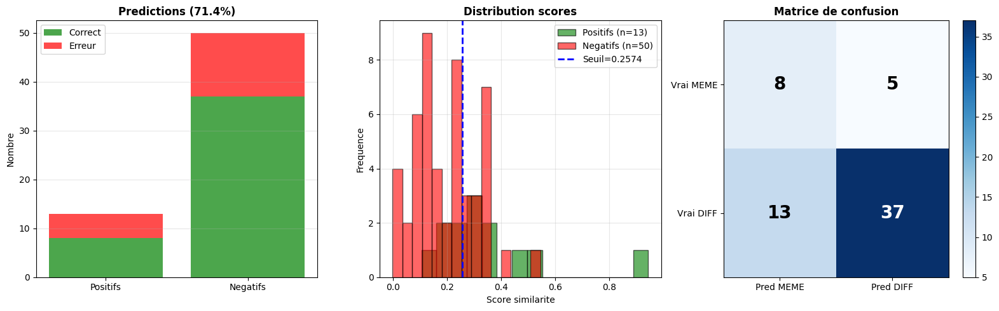

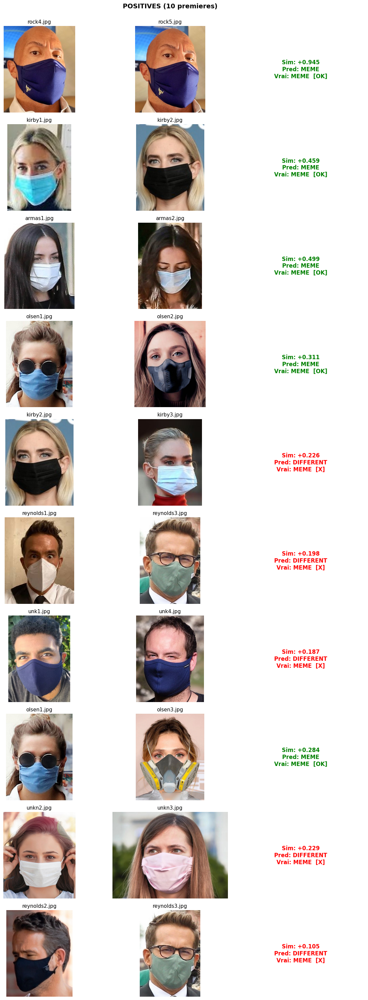

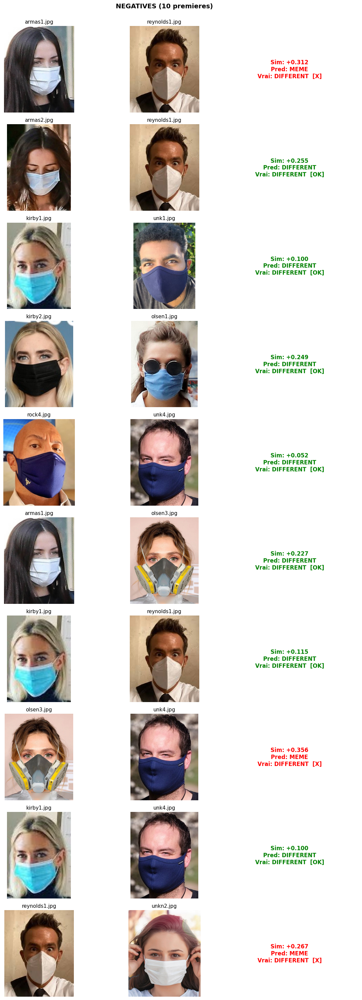

In [6]:
# ============================================================
# TEST SUR DATASET DU PROF
# Photos avec même nom + chiffre = même personne
# Exemple : armas1, armas2 → MÊME personne
#          armas1, evans1 → DIFFÉRENTES personnes
# ============================================================

import os
import re
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# ============================================================
# 1️⃣  CONFIGURATION
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/hibaelhamdani/verification-data/verificationTest"
MODEL_PATH   = "/kaggle/input/models/hibaelhamdani/mobilenetv3-maskedfacerecognition/pytorch/default/1/final_model.pt"

IMG_SIZE   = 224
EMBED_DIM  = 512
THRESHOLD  = 0.2574
MAX_PAIRES = 100         # Nombre de paires à tester
SEED       = 42          # Pour reproductibilité

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)

print(f"Device : {DEVICE}")
print(f"Seed   : {SEED}")
print(f"Max paires : {MAX_PAIRES}\n")


# ============================================================
# 2️⃣  ARCHITECTURE DU MODÈLE
# ============================================================

class FaceModel(nn.Module):
    """MobileNetV3-Large + tête d'embedding"""
    
    def __init__(self, embed_dim=512):
        super().__init__()
        weights       = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        base          = models.mobilenet_v3_large(weights=weights)
        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)
        self.head     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)


# ============================================================
# 3️⃣  CHARGEMENT DU MODÈLE
# ============================================================

def charger_modele():
    """Charge le modèle pré-entraîné depuis Kaggle"""
    print("Chargement du modele...")
    model = FaceModel(EMBED_DIM).to(DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model.eval()
    print("✅ Modele charge !\n")
    return model


# ============================================================
# 4️⃣  PRÉPROCESSING
# ============================================================

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    ),
])


# ============================================================
# 5️⃣  UTILITAIRES DATASET
# ============================================================

def extraire_nom_personne(nom_fichier):
    """
    Extrait le nom de la personne depuis le nom du fichier
    
    Exemples :
        armas1.jpg → 'armas'
        kirby3.jpg → 'kirby'
    """
    nom_sans_ext = os.path.splitext(nom_fichier)[0]
    nom_personne = re.sub(r'\d+$', '', nom_sans_ext)
    return nom_personne.lower()


def lister_images_dataset():
    """Liste toutes les images du dataset avec leurs métadonnées"""
    images = []
    for f in sorted(os.listdir(DATASET_PATH)):
        if f.lower().endswith(('.jpg', '.png', '.jpeg')):
            images.append({
                'path'    : os.path.join(DATASET_PATH, f),
                'fichier' : f,
                'personne': extraire_nom_personne(f),
            })
    return images


# ============================================================
# 6️⃣  EXTRACTION DES EMBEDDINGS (BATCH)
# ============================================================

def extraire_tous_embeddings(model, images, batch_size=16):
    """Extrait les embeddings de toutes les images en batch (rapide)"""
    paths = [img['path'] for img in images]
    embeddings = []

    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i + batch_size]
        
        # Charger et transformer
        tensors = []
        for p in batch_paths:
            img = Image.open(p).convert("RGB")
            tensors.append(transform(img))
        
        # Inférence
        batch = torch.stack(tensors).to(DEVICE)
        with torch.no_grad():
            embs = model(batch)
        embeddings.append(embs.cpu())

    # Associer chaque embedding à son image
    all_embs = torch.cat(embeddings, dim=0)
    for i, img in enumerate(images):
        img['embedding'] = all_embs[i]
    
    return images


# ============================================================
# 7️⃣  COMPARAISON DES EMBEDDINGS
# ============================================================

def comparer_embeddings(emb1, emb2):
    """Calcule la similarité cosinus et la prédiction"""
    score = F.cosine_similarity(
        emb1.unsqueeze(0),
        emb2.unsqueeze(0)
    ).item()
    meme = score > THRESHOLD
    return meme, score


# ============================================================
# 8️⃣  GÉNÉRATION DES PAIRES
# ============================================================

def generer_toutes_paires(images):
    """Génère toutes les paires possibles avec scores et prédictions"""
    paires = []
    for img1, img2 in combinations(images, 2):
        label_vrai  = (img1['personne'] == img2['personne'])
        meme, score = comparer_embeddings(img1['embedding'], img2['embedding'])
        correct     = (meme == label_vrai)
        
        paires.append({
            'img1'      : img1,
            'img2'      : img2,
            'label_vrai': label_vrai,
            'score'     : score,
            'pred'      : meme,
            'correct'   : correct,
        })
    return paires


def selectionner_paires_equilibrees(paires, max_paires):
    """Sélectionne max_paires en équilibrant positifs/négatifs"""
    pos = [p for p in paires if p['label_vrai']]
    neg = [p for p in paires if not p['label_vrai']]
    
    n_pos_voulu = max_paires // 2
    n_neg_voulu = max_paires - n_pos_voulu
    
    n_pos = min(n_pos_voulu, len(pos))
    n_neg = min(n_neg_voulu, len(neg))
    
    pos_select = random.sample(pos, n_pos)
    neg_select = random.sample(neg, n_neg)
    
    return pos_select, neg_select


# ============================================================
# 9️⃣  AFFICHAGE TEXTE
# ============================================================

def afficher_apercu_dataset(images, personnes):
    """Affiche un aperçu du dataset chargé"""
    print("="*60)
    print("   APERCU DU DATASET")
    print("="*60)
    print(f"  Nombre d'images   : {len(images)}")
    print(f"  Personnes uniques : {len(personnes)}")
    print(f"  Liste personnes   : {personnes}\n")
    print("  Images par personne :")
    for p in personnes:
        n = sum(1 for img in images if img['personne'] == p)
        print(f"    {p:15s} : {n} image(s)")
    print()


def afficher_resultats_paires(paires, titre):
    """Affiche les résultats détaillés des paires"""
    print("="*60)
    print(f"   {titre}")
    print("="*60)
    for p in paires:
        symbole = "OK    " if p['correct'] else "ERREUR"
        pred    = "MEME" if p['pred'] else "DIFF"
        vrai    = "MEME" if p['label_vrai'] else "DIFF"
        print(f"  {p['img1']['fichier']:12s} vs {p['img2']['fichier']:12s} | "
              f"score={p['score']:+.3f} | "
              f"pred={pred} | vrai={vrai} | [{symbole}]")
    print()


def afficher_resume_textuel(paires_pos, paires_neg, correct_pos, correct_neg):
    """Affiche le résumé textuel des performances"""
    n_pos     = len(paires_pos)
    n_neg     = len(paires_neg)
    total     = n_pos + n_neg
    correct   = correct_pos + correct_neg
    precision = correct / total * 100 if total > 0 else 0

    TP = correct_pos
    FN = n_pos - correct_pos
    TN = correct_neg
    FP = n_neg - correct_neg

    scores_pos = [p['score'] for p in paires_pos]
    scores_neg = [p['score'] for p in paires_neg]

    print("="*60)
    print("   RESUME DES PERFORMANCES")
    print("="*60)
    print(f"  Total paires testees  : {total}")
    print(f"  Predictions correctes : {correct}")
    print(f"  PRECISION GLOBALE     : {precision:.1f}%")
    print()
    print(f"  --- Matrice de confusion ---")
    print(f"  TP (Vrais Positifs)   : {TP}/{n_pos}")
    print(f"  FN (Faux Negatifs)    : {FN}/{n_pos}")
    print(f"  TN (Vrais Negatifs)   : {TN}/{n_neg}")
    print(f"  FP (Faux Positifs)    : {FP}/{n_neg}")
    print()
    if scores_pos:
        print(f"  Score moyen positifs  : {np.mean(scores_pos):+.3f}")
    if scores_neg:
        print(f"  Score moyen negatifs  : {np.mean(scores_neg):+.3f}")
    print("="*60 + "\n")


# ============================================================
# 🔟  AFFICHAGE GRAPHIQUE
# ============================================================

def afficher_graphiques(paires_pos, paires_neg, correct_pos, correct_neg):
    """Affiche bar chart + distribution + matrice de confusion"""
    n_pos     = len(paires_pos)
    n_neg     = len(paires_neg)
    total     = n_pos + n_neg
    correct   = correct_pos + correct_neg
    precision = correct / total * 100 if total > 0 else 0

    TP = correct_pos
    FN = n_pos - correct_pos
    TN = correct_neg
    FP = n_neg - correct_neg

    scores_pos = [p['score'] for p in paires_pos]
    scores_neg = [p['score'] for p in paires_neg]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ── Bar chart : correct vs erreur ──────────────────────
    cats    = ["Positifs", "Negatifs"]
    bons    = [correct_pos, correct_neg]
    erreurs = [n_pos - correct_pos, n_neg - correct_neg]
    x = np.arange(len(cats))
    
    axes[0].bar(x, bons,    color="green", alpha=0.7, label="Correct")
    axes[0].bar(x, erreurs, bottom=bons, color="red", alpha=0.7, label="Erreur")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(cats)
    axes[0].set_ylabel("Nombre")
    axes[0].set_title(f"Predictions ({precision:.1f}%)", fontweight="bold")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    # ── Distribution des scores ─────────────────────────────
    if scores_pos:
        axes[1].hist(scores_pos, bins=15, alpha=0.6, color="green",
                     label=f"Positifs (n={n_pos})", edgecolor="black")
    if scores_neg:
        axes[1].hist(scores_neg, bins=15, alpha=0.6, color="red",
                     label=f"Negatifs (n={n_neg})", edgecolor="black")
    axes[1].axvline(THRESHOLD, color="blue", linestyle="--",
                    linewidth=2, label=f"Seuil={THRESHOLD}")
    axes[1].set_xlabel("Score similarite")
    axes[1].set_ylabel("Frequence")
    axes[1].set_title("Distribution scores", fontweight="bold")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # ── Matrice de confusion ────────────────────────────────
    matrice = np.array([[TP, FN], [FP, TN]])
    im = axes[2].imshow(matrice, cmap="Blues", aspect="auto")
    axes[2].set_xticks([0, 1])
    axes[2].set_yticks([0, 1])
    axes[2].set_xticklabels(["Pred MEME", "Pred DIFF"])
    axes[2].set_yticklabels(["Vrai MEME", "Vrai DIFF"])
    axes[2].set_title("Matrice de confusion", fontweight="bold")

    for i in range(2):
        for j in range(2):
            color = "white" if matrice[i, j] > matrice.max() / 2 else "black"
            axes[2].text(j, i, str(matrice[i, j]),
                         ha="center", va="center",
                         fontsize=20, fontweight="bold", color=color)

    plt.colorbar(im, ax=axes[2])
    plt.tight_layout()
    plt.show()


# ============================================================
# 1️⃣1️⃣  AFFICHAGE DES PAIRES (IMAGES)
# ============================================================

def afficher_grille_paires(paires, titre):
    """Affiche les paires d'images avec leurs résultats"""
    if len(paires) == 0:
        return

    n = len(paires)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3 * n))

    if n == 1:
        axes = axes.reshape(1, -1)

    fig.suptitle(titre, fontsize=14, fontweight="bold", y=1.00)

    for i, p in enumerate(paires):
        couleur = "green" if p['correct'] else "red"
        symbole = "OK" if p['correct'] else "X"
        pred    = "MEME" if p['pred'] else "DIFFERENT"
        vrai    = "MEME" if p['label_vrai'] else "DIFFERENT"

        # Photo 1
        img1 = Image.open(p['img1']['path']).convert("RGB")
        axes[i, 0].imshow(img1)
        axes[i, 0].set_title(p['img1']['fichier'], fontsize=11)
        axes[i, 0].axis("off")

        # Photo 2
        img2 = Image.open(p['img2']['path']).convert("RGB")
        axes[i, 1].imshow(img2)
        axes[i, 1].set_title(p['img2']['fichier'], fontsize=11)
        axes[i, 1].axis("off")

        # Résultat
        axes[i, 2].axis("off")
        texte = (f"Sim: {p['score']:+.3f}\n"
                 f"Pred: {pred}\n"
                 f"Vrai: {vrai}  [{symbole}]")
        axes[i, 2].text(0.5, 0.5, texte,
                        ha="center", va="center",
                        fontsize=12, fontweight="bold",
                        color=couleur,
                        transform=axes[i, 2].transAxes)

    plt.tight_layout()
    plt.show()


# ============================================================
# 1️⃣2️⃣  PIPELINE PRINCIPAL
# ============================================================

def evaluation_dataset(max_paires=MAX_PAIRES):
    """Pipeline complet d'évaluation"""
    
    print("="*60)
    print(f"   EVALUATION SUR DATASET DU PROF")
    print(f"   (Max {max_paires} paires)")
    print("="*60 + "\n")

    # ── Étape 1 : Charger le modèle ────────────────────────
    model = charger_modele()

    # ── Étape 2 : Lister les images ────────────────────────
    images = lister_images_dataset()
    if len(images) == 0:
        print("❌ Aucune image trouvee dans :", DATASET_PATH)
        return None
    
    personnes = sorted(set(img['personne'] for img in images))
    afficher_apercu_dataset(images, personnes)

    # ── Étape 3 : Extraire les embeddings ──────────────────
    print("Extraction des embeddings...")
    images = extraire_tous_embeddings(model, images)
    print(f"✅ {len(images)} embeddings extraits\n")

    # ── Étape 4 : Générer toutes les paires ────────────────
    print("Generation des paires...")
    toutes_paires = generer_toutes_paires(images)
    print(f"✅ {len(toutes_paires)} paires possibles\n")

    # ── Étape 5 : Sélectionner N paires équilibrées ────────
    paires_pos, paires_neg = selectionner_paires_equilibrees(
        toutes_paires, max_paires
    )
    print(f"Paires selectionnees pour le test :")
    print(f"  Positives : {len(paires_pos)}")
    print(f"  Negatives : {len(paires_neg)}")
    print(f"  TOTAL     : {len(paires_pos) + len(paires_neg)}\n")

    # ── Étape 6 : Calculer les performances ────────────────
    correct_pos = sum(1 for p in paires_pos if p['correct'])
    correct_neg = sum(1 for p in paires_neg if p['correct'])

    # ── Étape 7 : Afficher les résultats détaillés ─────────
    afficher_resultats_paires(paires_pos, "PAIRES POSITIVES (meme personne)")
    afficher_resultats_paires(paires_neg, "PAIRES NEGATIVES (differentes)")

    # ── Étape 8 : Résumé textuel ───────────────────────────
    afficher_resume_textuel(paires_pos, paires_neg, correct_pos, correct_neg)

    # ── Étape 9 : Graphiques ───────────────────────────────
    afficher_graphiques(paires_pos, paires_neg, correct_pos, correct_neg)

    # ── Étape 10 : Affichage visuel (10 premières) ─────────
    afficher_grille_paires(paires_pos[:10], "POSITIVES (10 premieres)")
    afficher_grille_paires(paires_neg[:10], "NEGATIVES (10 premieres)")

    return {
        'paires_pos'  : paires_pos,
        'paires_neg'  : paires_neg,
        'correct_pos' : correct_pos,
        'correct_neg' : correct_neg,
    }


# ============================================================
# 1️⃣3️⃣  EXÉCUTION
# ============================================================

if __name__ == "__main__":
    resultats = evaluation_dataset(max_paires=100)

amélioration des image au niveau de gris

In [ ]:
# ============================================================
# MASKED FACE VERIFICATION — GRAYSCALE VERSION
# Fine-tuning Progressif + Batch Hard Triplet Loss
# + Courbe ROC + Sauvegarde complète
# ============================================================

import os, random, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')   # backend non-interactif (Kaggle / headless)
from IPython.display import FileLink, display

# =====================
# 1️⃣  CONFIG
# =====================
ROOT          = "/kaggle/input/datasets/hibaelhamdani/data-final-augmenter/GLOBAL_DATASET"
IMG_SIZE      = 224
EPOCHS        = 40
WARMUP_EPOCHS = 5        # epochs avec backbone gelé
LR            = 1e-3
LR_BACKBONE   = 1e-4    # LR réduit pour MobileNet en phase 2
EMBED_DIM     = 512
MARGIN        = 0.5
P             = 18       # personnes par batch
K             = 6        # images par personne
BATCH_SIZE    = P * K    # = 108
NUM_WORKERS   = 4
PATIENCE      = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Device : {DEVICE}")

# ── Seed ────────────────────────────────────────────────────
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# =====================
# 2️⃣  SPLIT
# =====================
persons = sorted([
    p for p in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, p))
])

def is_valid(person):
    counts = {}
    for typ in ["masked", "non_masked"]:
        folder = os.path.join(ROOT, person, typ)
        counts[typ] = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ]) if os.path.isdir(folder) else 0
    return counts.get("masked", 0) >= 2 and counts.get("non_masked", 0) >= 2

valid_persons = [p for p in persons if is_valid(p)]
print(f"Personnes valides : {len(valid_persons)}")

random.shuffle(valid_persons)
n = len(valid_persons)
train_persons = valid_persons[:int(0.70 * n)]
val_persons   = valid_persons[int(0.70 * n):int(0.85 * n)]
test_persons  = valid_persons[int(0.85 * n):]
print(f"Train : {len(train_persons)} | Val : {len(val_persons)} | Test : {len(test_persons)}")

# =====================
# 3️⃣  TRANSFORMS — GRAYSCALE
# =====================
# ⚠️  Changement clé :
#   • Grayscale(num_output_channels=3) : convertit en gris MAIS garde 3 canaux
#     identiques → compatible MobileNetV3 (attend 3 canaux) sans modifier l'archi.
#   • Normalisation ImageNet maintenue (valeurs identiques sur les 3 canaux).

grayscale_op = transforms.Grayscale(num_output_channels=3)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    # Pas de ColorJitter (inutile en gris) — remplacé par brightness/contrast seulement
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    grayscale_op,                   # ← conversion niveaux de gris
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    grayscale_op,                   # ← conversion niveaux de gris
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# =====================
# 4️⃣  DATASET
# =====================
class FaceDataset(Dataset):
    def __init__(self, root, persons, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for idx, p in enumerate(persons):
            for typ in ["masked", "non_masked"]:
                folder = os.path.join(root, p, typ)
                if not os.path.isdir(folder):
                    continue
                for f in os.listdir(folder):
                    if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.samples.append((os.path.join(folder, f), idx))
                        self.labels.append(idx)

        print(f"  Dataset : {len(self.samples)} images, {len(persons)} personnes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")   # on charge en RGB d'abord
        if self.transform:
            img = self.transform(img)            # puis grayscale dans le transform
        return img, label

# =====================
# 5️⃣  PK SAMPLER
# =====================
class PKSampler(Sampler):
    def __init__(self, labels, P=18, K=6):
        self.labels = np.array(labels)
        self.P, self.K = P, K

        self.label_to_idxs = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            self.label_to_idxs[lbl].append(i)

        self.valid_labels = [
            lbl for lbl, idxs in self.label_to_idxs.items()
            if len(idxs) >= K
        ]
        self.n_batches = len(self.labels) // (P * K)
        print(f"  PKSampler : {len(self.valid_labels)} personnes | "
              f"P={P}, K={K} | {self.n_batches} batches/epoch")

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen = random.sample(
                self.valid_labels, min(self.P, len(self.valid_labels))
            )
            for lbl in chosen:
                idxs = random.choices(self.label_to_idxs[lbl], k=self.K)
                batch.extend(idxs)
            yield batch

    def __len__(self):
        return self.n_batches

# =====================
# 6️⃣  DATALOADERS
# =====================
train_ds = FaceDataset(ROOT, train_persons, train_tf)
val_ds   = FaceDataset(ROOT, val_persons,   val_tf)

train_sampler = PKSampler(train_ds.labels, P=P, K=K)
val_sampler   = PKSampler(val_ds.labels,
                          P=min(P, len(val_persons) // 2), K=K)

train_loader = DataLoader(train_ds, batch_sampler=train_sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_sampler=val_sampler,
                          num_workers=NUM_WORKERS, pin_memory=True)

# =====================
# 7️⃣  MODÈLE
# =====================
class FaceModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        base = models.mobilenet_v3_large(weights=weights)

        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)   # L2 normalisé

    def freeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = False
        print("  Backbone GELÉ")

    def unfreeze_backbone(self):
        for p in self.features.parameters():
            p.requires_grad = True
        print("  Backbone DÉGELÉ")

model = FaceModel(EMBED_DIM).to(DEVICE)
print(f"Paramètres total : {sum(p.numel() for p in model.parameters()):,}")

# =====================
# 8️⃣  BATCH HARD TRIPLET LOSS
# =====================
def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    B = embeddings.size(0)
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1)

    same     = labels.unsqueeze(0) == labels.unsqueeze(1)
    eye      = torch.eye(B, dtype=torch.bool, device=DEVICE)
    pos_mask = same & ~eye
    neg_mask = ~same

    dist_ap  = (dist * pos_mask.float()).max(dim=1)[0]
    inf_mask = (~neg_mask).float() * 1e9
    dist_an  = (dist + inf_mask).min(dim=1)[0]

    valid = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    if valid.sum() == 0:
        return embeddings.sum() * 0, 0.0

    losses = F.relu(dist_ap[valid] - dist_an[valid] + margin)
    return losses.mean(), (losses > 0).float().mean().item()

# =====================
# 9️⃣  ENTRAÎNEMENT
# =====================
model.freeze_backbone()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)
scheduler = CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS, eta_min=1e-5)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss    = float('inf')
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "active_frac": [], "phase": []}

print("\n" + "="*60)
print("PHASE 1 — Backbone gelé (warmup)")
print("="*60)

for epoch in range(EPOCHS):

    # ── Passage Phase 1 → Phase 2 ────────────────────────────
    if epoch == WARMUP_EPOCHS:
        model.unfreeze_backbone()
        optimizer = torch.optim.AdamW([
            {'params': model.features.parameters(), 'lr': LR_BACKBONE},
            {'params': model.head.parameters(),     'lr': LR}
        ], weight_decay=1e-4)
        scheduler = CosineAnnealingLR(
            optimizer, T_max=EPOCHS - WARMUP_EPOCHS, eta_min=1e-6
        )
        print("\n" + "="*60)
        print(f"PHASE 2 — Fine-tuning complet")
        print(f"  Backbone LR = {LR_BACKBONE} | Tête LR = {LR}")
        print("="*60)

    # ── TRAIN ─────────────────────────────────────────────────
    model.train()
    tl_sum = af_sum = nb = 0

    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            embs, active = model(imgs), None
            loss, active = batch_hard_triplet_loss(embs, labels, MARGIN)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        tl_sum += loss.item(); af_sum += active; nb += 1

    avg_train  = tl_sum / max(nb, 1)
    avg_active = af_sum / max(nb, 1)

    # ── VALIDATION ────────────────────────────────────────────
    model.eval()
    vl_sum = vb = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                embs = model(imgs)
                loss, _ = batch_hard_triplet_loss(embs, labels, MARGIN)
            vl_sum += loss.item(); vb += 1

    avg_val = vl_sum / max(vb, 1)
    scheduler.step()

    phase = "warmup" if epoch < WARMUP_EPOCHS else "finetune"
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["active_frac"].append(avg_active)
    history["phase"].append(phase)

    improved = avg_val < best_val_loss
    if improved:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save({
            'epoch':             epoch,
            'model_state_dict':  model.state_dict(),
            'optimizer_state':   optimizer.state_dict(),
            'val_loss':          best_val_loss,
            'config': {
                'embed_dim': EMBED_DIM, 'img_size': IMG_SIZE,
                'margin': MARGIN, 'mode': 'grayscale'
            }
        }, "/kaggle/working/best_model.pt")
    else:
        patience_counter += 1

    cur_lr = optimizer.param_groups[-1]['lr']
    status = "✅ best" if improved else f"⏳ ({patience_counter}/{PATIENCE})"
    print(f"Epoch {epoch+1:>3}/{EPOCHS} | [{phase:8s}] | "
          f"Train {avg_train:.4f} | Val {avg_val:.4f} | "
          f"Active {avg_active:.1%} | LR {cur_lr:.2e} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\n Early stopping à l'epoch {epoch+1}")
        break

print(f"\n Meilleure val loss : {best_val_loss:.4f}")

# =====================
# 🔟  ÉVALUATION BIOMÉTRIQUE
# =====================
checkpoint = torch.load("/kaggle/working/best_model.pt")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"\nMeilleur modèle : epoch {checkpoint['epoch']+1}")

def get_embedding(img_path):
    img    = Image.open(img_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(tensor)
    return emb.cpu()

def build_test_pairs(persons, n_pairs=3000):
    scores, labels_out = [], []
    valid = [
        p for p in persons
        if os.path.isdir(os.path.join(ROOT, p, "masked"))
        and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
    ]
    print(f"  Personnes test valides : {len(valid)}")

    def rand_img(person, typ):
        folder = os.path.join(ROOT, person, typ)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg','.png','.jpeg'))]
        return os.path.join(folder, random.choice(files))

    for _ in range(n_pairs):
        p = random.choice(valid)

        # Positif 1 : non_masked → masked
        e1 = get_embedding(rand_img(p, "non_masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item()); labels_out.append(1)

        # Positif 2 : masked → masked
        e1 = get_embedding(rand_img(p, "masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item()); labels_out.append(1)

        # Négatif : deux personnes différentes
        p2 = random.choice([x for x in valid if x != p])
        t1 = random.choice(["masked", "non_masked"])
        t2 = random.choice(["masked", "non_masked"])
        e1 = get_embedding(rand_img(p,  t1))
        e2 = get_embedding(rand_img(p2, t2))
        scores.append(F.cosine_similarity(e1, e2).item()); labels_out.append(0)

    return np.array(scores), np.array(labels_out)

print("\n Construction des paires de test...")
scores, labels_eval = build_test_pairs(test_persons, n_pairs=3000)
print(f"  Total : {len(scores)} paires | "
      f"Positifs : {labels_eval.sum()} | Négatifs : {(1-labels_eval).sum()}")

# ── Métriques ─────────────────────────────────────────────────
auc = roc_auc_score(labels_eval, scores)
fpr, tpr, thresholds = roc_curve(labels_eval, scores)

fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = float(fpr[eer_idx])

def tar_at_far(target):
    idx = np.searchsorted(fpr, target, side='right') - 1
    return float(tpr[max(0, min(idx, len(tpr)-1))])

metrics = {
    "AUC"            : float(auc),
    "EER"            : float(eer),
    "EER_threshold"  : float(thresholds[eer_idx]),
    "TAR@EER"        : float(tpr[eer_idx]),
    "TAR@FAR=0.0001" : tar_at_far(1e-4),
    "TAR@FAR=0.001"  : tar_at_far(1e-3),
    "TAR@FAR=0.01"   : tar_at_far(1e-2),
    "TAR@FAR=0.1"    : tar_at_far(0.1),
    "mode"           : "grayscale",
}

print("\n RÉSULTATS BIOMÉTRIQUES — GRAYSCALE")
print("-" * 45)
for k, v in metrics.items():
    if k == "mode":
        print(f"  {'mode':<22}: {v}"); continue
    q = ""
    if k == "AUC": q = "🟢" if v > 0.90 else "🟡" if v > 0.80 else "🔴"
    if k == "EER": q = "🟢" if v < 0.10 else "🟡" if v < 0.20 else "🔴"
    print(f"  {k:<22}: {v:.4f} {q}")

# =====================
# 📈  COURBE ROC
# =====================
def plot_roc(fpr, tpr, auc, eer, eer_idx, save_path):
    fig, ax = plt.subplots(figsize=(8, 7))
    fig.patch.set_facecolor('#0f1117')
    ax.set_facecolor('#0f1117')

    # Courbe principale
    ax.plot(fpr, tpr, color='#00d4ff', lw=2.5,
            label=f'ROC — AUC = {auc:.4f}')

    # Diagonale aléatoire
    ax.plot([0, 1], [0, 1], color='#555', lw=1, linestyle='--',
            label='Aléatoire (AUC = 0.50)')

    # Point EER
    ax.scatter(fpr[eer_idx], tpr[eer_idx], color='#ff4d6d',
               s=120, zorder=5, label=f'EER = {eer:.4f}')
    ax.axhline(tpr[eer_idx], color='#ff4d6d', lw=0.8, linestyle=':')
    ax.axvline(fpr[eer_idx], color='#ff4d6d', lw=0.8, linestyle=':')

    # Points TAR@FAR
    for far_val, color in [(1e-3, '#ffd166'), (1e-2, '#06d6a0')]:
        idx    = np.searchsorted(fpr, far_val, side='right') - 1
        idx    = max(0, min(idx, len(tpr)-1))
        label  = f'TAR@FAR={far_val:.3f} = {tpr[idx]:.4f}'
        ax.scatter(fpr[idx], tpr[idx], color=color, s=90, zorder=5, label=label)

    # Remplissage sous la courbe
    ax.fill_between(fpr, tpr, alpha=0.08, color='#00d4ff')

    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.01])
    ax.set_xlabel('False Positive Rate (FAR)', color='#ccc', fontsize=12)
    ax.set_ylabel('True Positive Rate (TAR)', color='#ccc', fontsize=12)
    ax.set_title('Courbe ROC — Masked Face Verification (Grayscale)',
                 color='white', fontsize=14, pad=15)

    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

    legend = ax.legend(loc='lower right', framealpha=0.2,
                       facecolor='#1a1a2e', edgecolor='#333',
                       labelcolor='white', fontsize=10)

    ax.grid(True, color='#222', linewidth=0.6)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Courbe ROC sauvegardée → {save_path}")

plot_roc(fpr, tpr, auc, eer, eer_idx,
         "/kaggle/working/roc_curve_grayscale.png")

# ── Courbe de training ────────────────────────────────────────
def plot_training_history(history, save_path):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    warmup_end   = sum(1 for p in history["phase"] if p == "warmup")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('#0f1117')

    for ax in axes:
        ax.set_facecolor('#0f1117')
        ax.tick_params(colors='#aaa')
        for sp in ax.spines.values(): sp.set_edgecolor('#333')
        ax.grid(True, color='#222', linewidth=0.6)

    # Subplot 1 — Loss
    ax = axes[0]
    ax.plot(epochs_range, history["train_loss"], color='#00d4ff', lw=2, label='Train Loss')
    ax.plot(epochs_range, history["val_loss"],   color='#ff4d6d', lw=2, label='Val Loss')
    ax.axvline(warmup_end + 0.5, color='#ffd166', lw=1.2,
               linestyle='--', label='Fin warmup / Fine-tune')
    ax.set_title('Loss', color='white', fontsize=13)
    ax.set_xlabel('Epoch', color='#ccc'); ax.set_ylabel('Loss', color='#ccc')
    ax.legend(labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#333', framealpha=0.3, fontsize=10)

    # Subplot 2 — Triplets actifs
    ax = axes[1]
    ax.plot(epochs_range, [a * 100 for a in history["active_frac"]],
            color='#06d6a0', lw=2, label='Triplets actifs (%)')
    ax.axvline(warmup_end + 0.5, color='#ffd166', lw=1.2,
               linestyle='--', label='Fin warmup / Fine-tune')
    ax.set_title('Fraction de triplets actifs', color='white', fontsize=13)
    ax.set_xlabel('Epoch', color='#ccc')
    ax.set_ylabel('Actifs (%)', color='#ccc')
    ax.legend(labelcolor='white', facecolor='#1a1a2e',
              edgecolor='#333', framealpha=0.3, fontsize=10)

    plt.suptitle('Historique d\'entraînement — Grayscale',
                 color='white', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.close()
    print(f"  Historique sauvegardé → {save_path}")

plot_training_history(history, "/kaggle/working/training_history_grayscale.png")

# =====================
# 💾  SAUVEGARDE COMPLÈTE
# =====================
# Modèle final (dernier état)
torch.save(model.state_dict(),
           "/kaggle/working/final_model_grayscale.pt")

# Checkpoint complet (pour reprise d'entraînement)
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'embed_dim':  EMBED_DIM,
        'img_size':   IMG_SIZE,
        'margin':     MARGIN,
        'mode':       'grayscale',
        'backbone':   'mobilenet_v3_large',
    },
    'metrics': metrics,
}, "/kaggle/working/checkpoint_grayscale_full.pt")

# Métriques et historique JSON
with open("/kaggle/working/metrics_grayscale.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("/kaggle/working/history_grayscale.json", "w") as f:
    json.dump(history, f, indent=4)

# Archive ZIP de tous les résultats
shutil.make_archive("/kaggle/working/RESULTS_GRAYSCALE", "zip", "/kaggle/working")
display(FileLink("/kaggle/working/RESULTS_GRAYSCALE.zip"))

print("\n" + "="*60)
print(" Sauvegarde complète terminée !")
print("  best_model.pt                  → meilleur checkpoint")
print("  final_model_grayscale.pt       → poids finaux")
print("  checkpoint_grayscale_full.pt   → checkpoint complet + config")
print("  metrics_grayscale.json         → métriques biométriques")
print("  history_grayscale.json         → courbes d'entraînement")
print("  roc_curve_grayscale.png        → courbe ROC")
print("  training_history_grayscale.png → loss & triplets actifs")
print("  RESULTS_GRAYSCALE.zip          → tout en un seul zip")
print("="*60)

Device : cuda
Personnes valides : 745
Train : 521 | Val : 112 | Test : 112
  Dataset : 9416 images, 521 personnes
  Dataset : 1905 images, 112 personnes
  PKSampler : 521 personnes | P=18, K=6 | 87 batches/epoch
  PKSampler : 112 personnes | P=18, K=6 | 17 batches/epoch
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 122MB/s] 


Paramètres total : 4,483,888
  Backbone GELÉ

PHASE 1 — Backbone gelé (warmup)
Epoch   1/40 | [warmup  ] | Train 0.6520 | Val 0.8425 | Active 100.0% | LR 9.05e-04 | ✅ best
Epoch   2/40 | [warmup  ] | Train 0.6423 | Val 0.7957 | Active 100.0% | LR 6.58e-04 | ✅ best
Epoch   3/40 | [warmup  ] | Train 0.6355 | Val 0.7573 | Active 100.0% | LR 3.52e-04 | ✅ best
Epoch   4/40 | [warmup  ] | Train 0.6314 | Val 0.7426 | Active 100.0% | LR 1.05e-04 | ✅ best
Epoch   5/40 | [warmup  ] | Train 0.6259 | Val 0.7310 | Active 100.0% | LR 1.00e-05 | ✅ best
  Backbone DÉGELÉ

PHASE 2 — Fine-tuning complet
  Backbone LR = 0.0001 | Tête LR = 0.001
Epoch   6/40 | [finetune] | Train 0.6360 | Val 0.7123 | Active 100.0% | LR 9.98e-04 | ✅ best
Epoch   7/40 | [finetune] | Train 0.6324 | Val 0.7021 | Active 100.0% | LR 9.92e-04 | ✅ best
Epoch   8/40 | [finetune] | Train 0.6272 | Val 0.6880 | Active 100.0% | LR 9.82e-04 | ✅ best
Epoch   9/40 | [finetune] | Train 0.6223 | Val 0.6760 | Active 100.0% | LR 9.68e-04 | ✅

affichage de courbe ROC

Device: cuda
Personnes valides : 745
Train: 521 | Val: 112 | Test: 112
  Dataset: 9416 images, 521 personnes
  Dataset: 1905 images, 112 personnes
  PKSampler: 521 personnes | P=18, K=6 | 87 batches/epoch
  PKSampler: 112 personnes | P=18, K=6 | 17 batches/epoch
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 151MB/s]


Paramètres total: 4,483,888
  Backbone GELÉ

PHASE 1 — Backbone gelé (warmup)
Epoch   1/40 | [warmup  ] | Train 0.6506 | Val 0.7994 | Active 100.0% | LR 9.05e-04 | ✅ best
Epoch   2/40 | [warmup  ] | Train 0.6414 | Val 0.7421 | Active 100.0% | LR 6.58e-04 | ✅ best
Epoch   3/40 | [warmup  ] | Train 0.6338 | Val 0.7038 | Active 100.0% | LR 3.52e-04 | ✅ best
Epoch   4/40 | [warmup  ] | Train 0.6316 | Val 0.6815 | Active 100.0% | LR 1.05e-04 | ✅ best
Epoch   5/40 | [warmup  ] | Train 0.6255 | Val 0.6884 | Active 100.0% | LR 1.00e-05 | ⏳ (1/10)
  Backbone DÉGELÉ

PHASE 2 — Fine-tuning complet
  Backbone LR = 0.0001 | Tête LR = 0.001
Epoch   6/40 | [finetune] | Train 0.6345 | Val 0.6819 | Active 100.0% | LR 9.98e-04 | ⏳ (2/10)
Epoch   7/40 | [finetune] | Train 0.6312 | Val 0.6820 | Active 100.0% | LR 9.92e-04 | ⏳ (3/10)
Epoch   8/40 | [finetune] | Train 0.6247 | Val 0.6679 | Active 100.0% | LR 9.82e-04 | ✅ best
Epoch   9/40 | [finetune] | Train 0.6185 | Val 0.6641 | Active 100.0% | LR 9.68e-0

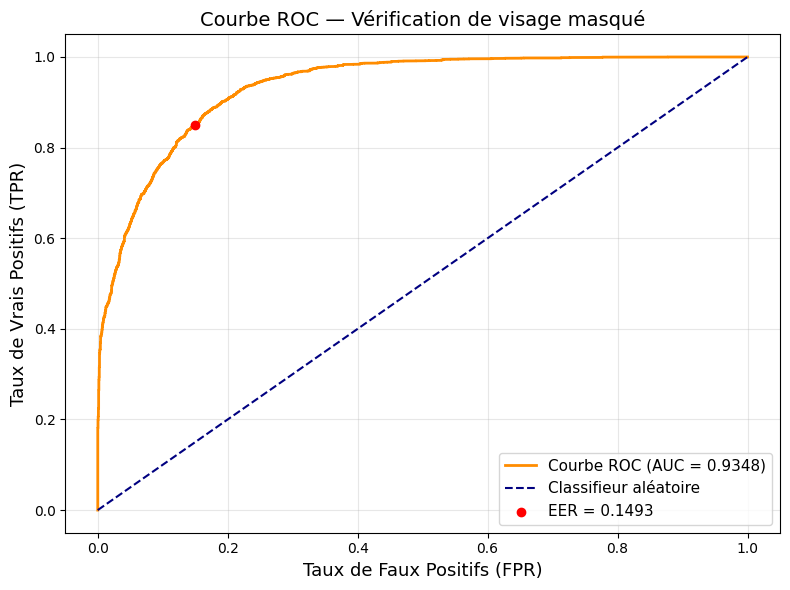

  Courbe ROC sauvegardée → roc_curve.png


OSError: [Errno 28] No space left on device

In [1]:
# ============================================================
# MASKED FACE VERIFICATION
# Fine-tuning Progressif + Batch Hard Triplet Loss
# ============================================================

import os, random, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.optim.lr_scheduler import OneCycleLR, CosineAnnealingLR
from PIL import Image
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import roc_curve, roc_auc_score
from collections import defaultdict
from IPython.display import FileLink
import matplotlib.pyplot as plt          # ← AJOUT UNIQUEMENT

# =====================
# 1️⃣ CONFIG
# =====================
ROOT        = "/kaggle/input/datasets/hibaelhamdani/data-final-augmenter/GLOBAL_DATASET"
IMG_SIZE    = 224
EPOCHS      = 40
WARMUP_EPOCHS = 5        # epochs avec backbone gelé
LR          = 1e-3
LR_BACKBONE = 1e-4       # LR plus petit pour MobileNet en phase 2
EMBED_DIM   = 512
MARGIN      = 0.5
P           = 18         # personnes par batch
K           = 6          # images par personne
BATCH_SIZE  = P * K      # = 108
NUM_WORKERS = 4
PATIENCE    = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
print(f"Device: {DEVICE}")

# Seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

# =====================
# 2️⃣ SPLIT
# =====================
persons = sorted([
    p for p in os.listdir(ROOT)
    if os.path.isdir(os.path.join(ROOT, p))
])

# Garder seulement les personnes avec au moins 2 masked + 2 non_masked
def is_valid(person):
    counts = {}
    for typ in ["masked", "non_masked"]:
        folder = os.path.join(ROOT, person, typ)
        if os.path.isdir(folder):
            counts[typ] = len([
                f for f in os.listdir(folder)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))
            ])
        else:
            counts[typ] = 0
    return counts.get("masked", 0) >= 2 and counts.get("non_masked", 0) >= 2

valid_persons = [p for p in persons if is_valid(p)]
print(f"Personnes valides : {len(valid_persons)}")

random.shuffle(valid_persons)
n = len(valid_persons)
train_persons = valid_persons[:int(0.70 * n)]
val_persons   = valid_persons[int(0.70 * n):int(0.85 * n)]
test_persons  = valid_persons[int(0.85 * n):]
print(f"Train: {len(train_persons)} | Val: {len(val_persons)} | Test: {len(test_persons)}")

# =====================
# 3️⃣ TRANSFORMS
# =====================
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomApply([transforms.GaussianBlur(3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# =====================
# 4️⃣ DATASET
# =====================
class FaceDataset(Dataset):
    def __init__(self, root, persons, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        for idx, p in enumerate(persons):
            for typ in ["masked", "non_masked"]:
                folder = os.path.join(root, p, typ)
                if not os.path.isdir(folder):
                    continue
                for f in os.listdir(folder):
                    if f.lower().endswith(('.jpg', '.png', '.jpeg')):
                        self.samples.append((os.path.join(folder, f), idx))
                        self.labels.append(idx)

        print(f"  Dataset: {len(self.samples)} images, {len(persons)} personnes")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# =====================
# 5️⃣ PK SAMPLER
# =====================
class PKSampler(Sampler):
    def __init__(self, labels, P=18, K=6):
        self.labels = np.array(labels)
        self.P = P
        self.K = K

        self.label_to_idxs = defaultdict(list)
        for i, lbl in enumerate(self.labels):
            self.label_to_idxs[lbl].append(i)

        # Personnes avec au moins K images
        self.valid_labels = [
            lbl for lbl, idxs in self.label_to_idxs.items()
            if len(idxs) >= K
        ]

        self.n_batches = len(self.labels) // (P * K)
        print(f"  PKSampler: {len(self.valid_labels)} personnes | "
              f"P={P}, K={K} | {self.n_batches} batches/epoch")

    def __iter__(self):
        for _ in range(self.n_batches):
            batch = []
            chosen = random.sample(
                self.valid_labels,
                min(self.P, len(self.valid_labels))
            )
            for lbl in chosen:
                idxs = random.choices(self.label_to_idxs[lbl], k=self.K)
                batch.extend(idxs)
            yield batch

    def __len__(self):
        return self.n_batches

# =====================
# 6️⃣ DATALOADERS
# =====================
train_ds = FaceDataset(ROOT, train_persons, train_tf)
val_ds   = FaceDataset(ROOT, val_persons,   val_tf)

train_sampler = PKSampler(train_ds.labels, P=P, K=K)
val_sampler   = PKSampler(val_ds.labels,
                          P=min(P, len(val_persons) // 2),
                          K=K)

train_loader = DataLoader(
    train_ds,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

# =====================
# 7️⃣ MODÈLE
# =====================
class FaceModel(nn.Module):
    def __init__(self, embed_dim=512):
        super().__init__()
        weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
        base = models.mobilenet_v3_large(weights=weights)

        self.features = base.features
        self.pool     = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(960, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
        )

        # Initialisation des couches linéaires
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.head(x)
        return F.normalize(x, dim=1)   # L2 normalisé

    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False
        print("  Backbone GELÉ")

    def unfreeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = True
        print("  Backbone DÉGELÉ")

model = FaceModel(EMBED_DIM).to(DEVICE)
total  = sum(p.numel() for p in model.parameters())
print(f"Paramètres total: {total:,}")

# =====================
# 8️⃣ BATCH HARD TRIPLET LOSS
# =====================
def batch_hard_triplet_loss(embeddings, labels, margin=0.5):
    B = embeddings.size(0)
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.view(-1)
    same    = labels.unsqueeze(0) == labels.unsqueeze(1)
    eye     = torch.eye(B, dtype=torch.bool, device=DEVICE)
    pos_mask = same & ~eye
    neg_mask = ~same
    dist_ap = (dist * pos_mask.float()).max(dim=1)[0]
    inf_mask = (~neg_mask).float() * 1e9
    dist_an  = (dist + inf_mask).min(dim=1)[0]
    valid = pos_mask.any(dim=1) & neg_mask.any(dim=1)
    if valid.sum() == 0:
        return embeddings.sum() * 0, 0.0
    dist_ap = dist_ap[valid]
    dist_an = dist_an[valid]
    losses = F.relu(dist_ap - dist_an + margin)
    active_frac = (losses > 0).float().mean().item()
    return losses.mean(), active_frac

# =====================
# 9️⃣ ENTRAÎNEMENT
# =====================

# ── PHASE 1 : Backbone gelé ─────────────────────────────────
model.freeze_backbone()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS, eta_min=1e-5)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss    = float('inf')
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "active_frac": [], "phase": []}

print("\n" + "="*60)
print("PHASE 1 — Backbone gelé (warmup)")
print("="*60)

for epoch in range(EPOCHS):

    # ── Passage Phase 1 → Phase 2 ───────────────────────────
    if epoch == WARMUP_EPOCHS:
        model.unfreeze_backbone()

        optimizer = torch.optim.AdamW([
            {'params': model.features.parameters(), 'lr': LR_BACKBONE},
            {'params': model.head.parameters(),     'lr': LR}
        ], weight_decay=1e-4)

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - WARMUP_EPOCHS,
            eta_min=1e-6
        )

        print("\n" + "="*60)
        print(f"PHASE 2 — Fine-tuning complet")
        print(f"  Backbone LR = {LR_BACKBONE} | Tête LR = {LR}")
        print("="*60)

    # ── TRAIN ────────────────────────────────────────────────
    model.train()
    train_loss_sum  = 0.0
    active_frac_sum = 0.0
    n_batches       = 0

    for imgs, labels in train_loader:
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda'):
            embs         = model(imgs)
            loss, active = batch_hard_triplet_loss(embs, labels, MARGIN)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss_sum  += loss.item()
        active_frac_sum += active
        n_batches       += 1

    avg_train  = train_loss_sum  / max(n_batches, 1)
    avg_active = active_frac_sum / max(n_batches, 1)

    # ── VALIDATION ───────────────────────────────────────────
    model.eval()
    val_loss_sum = 0.0
    v_batches    = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.amp.autocast('cuda'):
                embs         = model(imgs)
                loss, _      = batch_hard_triplet_loss(embs, labels, MARGIN)
            val_loss_sum += loss.item()
            v_batches    += 1

    avg_val = val_loss_sum / max(v_batches, 1)
    scheduler.step()

    phase = "warmup" if epoch < WARMUP_EPOCHS else "finetune"
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)
    history["active_frac"].append(avg_active)
    history["phase"].append(phase)

    improved = avg_val < best_val_loss
    if improved:
        best_val_loss    = avg_val
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': best_val_loss,
        }, "/kaggle/working/best_model.pt")
    else:
        patience_counter += 1

    status = "✅ best" if improved else f"⏳ ({patience_counter}/{PATIENCE})"
    cur_lr = optimizer.param_groups[-1]['lr']

    print(f"Epoch {epoch+1:>3}/{EPOCHS} | "
          f"[{phase:8s}] | "
          f"Train {avg_train:.4f} | "
          f"Val {avg_val:.4f} | "
          f"Active {avg_active:.1%} | "
          f"LR {cur_lr:.2e} | {status}")

    if patience_counter >= PATIENCE:
        print(f"\n Early stopping epoch {epoch+1}")
        break

print(f"\n Meilleure val loss : {best_val_loss:.4f}")

# =====================
# 🔟 ÉVALUATION BIOMÉTRIQUE
# =====================
checkpoint = torch.load("/kaggle/working/best_model.pt")
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"\nMeilleur modèle : epoch {checkpoint['epoch']+1}")

def get_embedding(img_path):
    img    = Image.open(img_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = model(tensor)
    return emb.cpu()

def build_test_pairs(persons, n_pairs=3000):
    scores, labels_out = [], []

    valid = [
        p for p in persons
        if os.path.isdir(os.path.join(ROOT, p, "masked"))
        and os.path.isdir(os.path.join(ROOT, p, "non_masked"))
    ]
    print(f"  Personnes test valides : {len(valid)}")

    def rand_img(person, typ):
        folder = os.path.join(ROOT, person, typ)
        files  = [f for f in os.listdir(folder)
                  if f.lower().endswith(('.jpg','.png','.jpeg'))]
        return os.path.join(folder, random.choice(files))

    for _ in range(n_pairs):
        p = random.choice(valid)

        e1 = get_embedding(rand_img(p, "non_masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(1)

        e1 = get_embedding(rand_img(p, "masked"))
        e2 = get_embedding(rand_img(p, "masked"))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(1)

        p2   = random.choice([x for x in valid if x != p])
        t1   = random.choice(["masked", "non_masked"])
        t2   = random.choice(["masked", "non_masked"])
        e1   = get_embedding(rand_img(p,  t1))
        e2   = get_embedding(rand_img(p2, t2))
        scores.append(F.cosine_similarity(e1, e2).item())
        labels_out.append(0)

    return np.array(scores), np.array(labels_out)

print("\n Construction des paires de test...")
scores, labels_eval = build_test_pairs(test_persons, n_pairs=3000)
print(f"  Total : {len(scores)} paires | "
      f"Positifs : {labels_eval.sum()} | "
      f"Négatifs : {(1-labels_eval).sum()}")

# ── Métriques ────────────────────────────────────────────────
auc = roc_auc_score(labels_eval, scores)
fpr, tpr, thresholds = roc_curve(labels_eval, scores)

fnr     = 1 - tpr
eer_idx = np.nanargmin(np.abs(fnr - fpr))
eer     = float(fpr[eer_idx])

def tar_at_far(target):
    idx = np.searchsorted(fpr, target, side='right') - 1
    idx = max(0, min(idx, len(tpr) - 1))
    return float(tpr[idx])

metrics = {
    "AUC"           : float(auc),
    "EER"           : float(eer),
    "EER_threshold" : float(thresholds[eer_idx]),
    "TAR@EER"       : float(tpr[eer_idx]),
    "TAR@FAR=0.0001": tar_at_far(1e-4),
    "TAR@FAR=0.001" : tar_at_far(1e-3),
    "TAR@FAR=0.01"  : tar_at_far(1e-2),
    "TAR@FAR=0.1"   : tar_at_far(0.1),
}

print("\n RÉSULTATS BIOMÉTRIQUES")
print("-" * 45)
for k, v in metrics.items():
    if k == "AUC":
        q = "🟢" if v > 0.90 else "🟡" if v > 0.80 else "🔴"
    elif k == "EER":
        q = "🟢" if v < 0.10 else "🟡" if v < 0.20 else "🔴"
    else:
        q = ""
    print(f"  {k:<22}: {v:.4f} {q}")

# =====================
# 📈 COURBE ROC / AUC  ← AJOUT UNIQUEMENT
# =====================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f"Courbe ROC (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], color='navy', lw=1.5,
         linestyle='--', label="Classifieur aléatoire")
plt.scatter(fpr[eer_idx], tpr[eer_idx], color='red', zorder=5,
            label=f"EER = {eer:.4f}")
plt.xlabel("Taux de Faux Positifs (FPR)", fontsize=13)
plt.ylabel("Taux de Vrais Positifs (TPR)", fontsize=13)
plt.title("Courbe ROC — Vérification de visage masqué", fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=150)
plt.show()
print("  Courbe ROC sauvegardée → roc_curve.png")
# =====================

# =====================
# SAUVEGARDE
# =====================
torch.save(model.state_dict(), "/kaggle/working/final_model.pt")

with open("/kaggle/working/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

with open("/kaggle/working/history.json", "w") as f:
    json.dump(history, f, indent=4)

shutil.make_archive("/kaggle/working/RESULTS", "zip", "/kaggle/working")
display(FileLink("/kaggle/working/RESULTS.zip"))
print("\n Sauvegarde terminée !")